# Project: Australian Market Expansion Strategy - 
## Workforce-Based Business Expansion Analytics
### Data Cleaning

### Description:

Goal:\
this document cleaned the restructured datasets from followling location:\
'/Users/abbottting/Desktop/Project/AMES/AustralianUnemployedPrediction/DataWrangling/RestructuredData/'\
The cleaned data would be save at the follwing location:\
'/Users/abbottting/Desktop/Project/AMES/AustralianUnemployedPrediction/DataWrangling/CleanedData/'


Language:&ensp;Python\
Library:&ensp;pandas, numpy, os, re, string, path, pyarrow\
Import Funtions Files:&ensp;ReadData_Functions.py, DataCleaning_Functions.py\
<br>
Data Source:&ensp;Australian Bureau of Statistics\
Datasets:\
&emsp;employment_status_western_auds.parquet, employment_status_tasmania.parquet,\
&emsp;employment_status_new_south_wales.parquet, employment_status_queensland.parquet,\
&emsp;employment_status_south_australia.parquet, employment_status_victoria.parquet, \
&emsp;erp_quarterly_unfiltered.parquet, employment_status_northern_territory.parquet, \
&emsp;job_vacancies.parquet, hourly_wages_rates_industry.parquet

## Part1. Library and datasets

### Library:

In [1]:
#!pip install seaborn

In [2]:
%load_ext autoreload
%autoreload 2

In [269]:
# Library
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path
import pyarrow
import seaborn as sns
# import re
# import string
    
# Functions
# Add the path of the folder containing your file
sys.path.append(os.path.abspath('/Users/abbottting/Desktop/Project/AMES/AustralianUnemployedPrediction'))
import ReadData_Functions as data_reader
import Restructure_Functions as restructure
import Analysis_Utils as analysis

### Files:

In [4]:
file_location = '/Users/abbottting/Desktop/Project/AMES/AustralianUnemployedPrediction/DataWrangling/RestructuredData'

In [5]:
files = data_reader.get_file_names_in_directory(file_location)
files

['employment_status_northern_territory.parquet',
 'job_vacancies_state.parquet',
 'employment_status_western_auds.parquet',
 'job_vacancies.parquet',
 'employment_status_queensland.parquet',
 'employment_status_victoria.parquet',
 'employment_status_new_south_wales.parquet',
 'erp_quarterly.parquet',
 'employment_status_tasmania.parquet',
 'employment_status_south_australia.parquet',
 'hourly_wages_rates_industry.parquet']

In [6]:
dataframes = data_reader.read_files_in_directory(directory = file_location, file_names = files)

Tracking initialized. Total files to read: 11
Expected files to read: 11
Successfully read files: 11
Success: Every single file path was successfully read!
All dataframes are listed below:
employment_status_northern_territory_original
job_vacancies_state_original
employment_status_western_auds_original
job_vacancies_original
employment_status_queensland_original
employment_status_victoria_original
employment_status_new_south_wales_original
erp_quarterly_original
employment_status_tasmania_original
employment_status_south_australia_original
hourly_wages_rates_industry_original


## Part2. Data Cleaning

#### Save all datasets here

In [7]:
cleaned_datasets = {}

### A. EmploymentStatus_NewSouthWales

In [8]:
employment_status_new_south_wales_Original= dataframes['employment_status_new_south_wales_original'].copy()


#### Observe and Analyse the dataset

over all\
categories: series_id, variale, gender, series_type\
datatime: date\
quantitative: value


Note: Because state column was created and it only contain on value in each datasets in employmentstatus datasets, we will not analyse is.

##### **Overall**

In [9]:
employment_status_new_south_wales_Original.head()

,date,series_id,state,variable,gender,series_type,value
0,1978-02-01,A84423937R,NewSouthWales,Employed total,Persons,Trend,2108.211696
1,1978-03-01,A84423937R,NewSouthWales,Employed total,Persons,Trend,2109.021527
2,1978-04-01,A84423937R,NewSouthWales,Employed total,Persons,Trend,2109.854462
3,1978-05-01,A84423937R,NewSouthWales,Employed total,Persons,Trend,2111.157961
4,1978-06-01,A84423937R,NewSouthWales,Employed total,Persons,Trend,2112.979788


In [10]:
employment_status_new_south_wales_Original.info()

<class 'pandas.DataFrame'>
RangeIndex: 48384 entries, 0 to 48383
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         48384 non-null  datetime64[us]
 1   series_id    48384 non-null  str           
 2   state        48384 non-null  str           
 3   variable     48384 non-null  str           
 4   gender       48384 non-null  str           
 5   series_type  48384 non-null  str           
 6   value        48384 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 5.5 MB


In [11]:
# Find duplicate in each observation
has_duplicates = employment_status_new_south_wales_Original.duplicated().any()
print(has_duplicates)

False


In [12]:
# find duplicate in each column
for one in employment_status_new_south_wales_Original.columns:
    individual_values = employment_status_new_south_wales_Original[one].is_unique
    print(f'{one}:{individual_values}')
    

date:False
series_id:False
state:False
variable:False
gender:False
series_type:False
value:False


In [13]:
employment_status_new_south_wales_Original.describe()

,date,value
count,48384,48384.000000
mean,2002-01-15 09:30:00,848.888573
min,1978-02-01 00:00:00,1.926685
25%,1990-01-24 06:00:00,52.289165
50%,2002-01-16 12:00:00,105.972091
75%,2014-01-08 18:00:00,1541.645416
max,2026-01-01 00:00:00,7148.465001
std,NaN,1160.668292


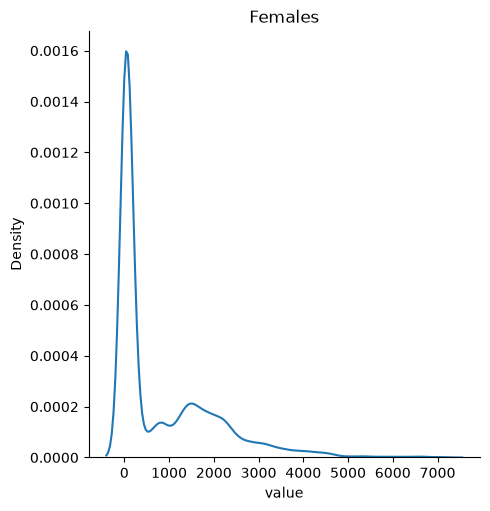

In [85]:
# data distribution
g = sns.displot(employment_status_new_south_wales_Original, x="value", kind="kde")
g.set(title=v)
display(g)
print('')

summary:
We can see that the data range is huge, with min in about 1.9 but the max reachse to more than 7000. From the distribution, we know alot of datas are actually small, which is lower than 1000. We know that we have different variables which most possble that it cause the diffence between the data range. However, we will futher investigate on that and check if other factors may cause this difference.

##### **Categories: series_id, variale, gender, series_type**


**over all**

In [14]:
# check for unique values on variabl, gender, series_type
selected_columns = ['variable', 'gender', 'series_type']
for column in selected_columns:
    unique_value = employment_status_new_south_wales_Original[column].unique()
    print(f'{column}:')
    print(unique_value)
    print('')

variable:
<ArrowStringArray>
[                                  'Employed total',
                               'Employed full-time',
                               'Employed part-time',
                   'Employment to population ratio',
                                 'Unemployed total',
             'Unemployed looked for full-time work',
        'Unemployed looked for only part-time work',
                                'Unemployment rate',
      'Unemployment rate looked for full-time work',
 'Unemployment rate looked for only part-time work',
                               'Labour force total',
                               'Participation rate',
                    'Not in the labour force (NILF',
       'Civilian population aged 15 years and over']
Length: 14, dtype: str

gender:
<ArrowStringArray>
['Persons', 'Males', 'Females']
Length: 3, dtype: str

series_type:
<ArrowStringArray>
['Trend', 'Seasonally Adjusted', 'Original']
Length: 3, dtype: str



In [15]:
# check for most frequent values
selected_columns = ['variable', 'gender', 'series_type']
dataset = employment_status_new_south_wales_Original
for column in selected_columns:
    most_frequent_value = dataset[column].mode()
    print(f'most frequent values in **{column}**:')
    print(most_frequent_value)
    print('')

most frequent values in **variable**:
0                Employed full-time
1                    Employed total
2    Employment to population ratio
3                Labour force total
4                Participation rate
5                  Unemployed total
6                 Unemployment rate
Name: variable, dtype: str

most frequent values in **gender**:
0    Females
1      Males
2    Persons
Name: gender, dtype: str

most frequent values in **series_type**:
0    Original
Name: series_type, dtype: str



**variable**

In [16]:
# range by variable
analysis.value_range(employment_status_new_south_wales_Original, 'variable', 'value')

Employed total:


'max: 4542.2100935, min: 730.0351111'


Employed full-time:


'max: 3200.3001985, min: 494.5381603'


Employed part-time:


...

'max: 79.7578768, min: 41.1075909'


Not in the labour force (NILF:


'max: 2530.0249803, min: 371.3828332'


Civilian population aged 15 years and over:


'max: 7148.465001, min: 1834.7029547'

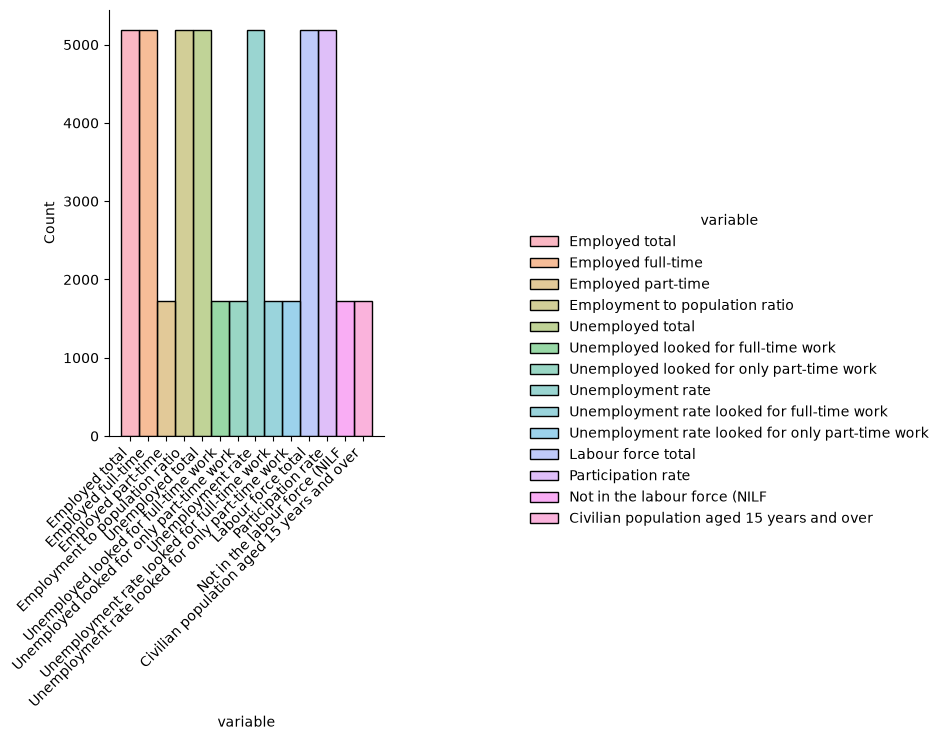

In [17]:
# how data distributed
g = sns.displot(
    employment_status_new_south_wales_Original, 
    x='variable', 
    hue='variable', 
    common_bins=False
)
# Rotate the x-axis labels for all subplots
g.set_xticklabels(rotation=45, ha='right')

In [ ]:
# notes: some variables have less data than the others

In [66]:
#outlier
variables = employment_status_new_south_wales_Original['variable'].unique()
categories_with_outliers_in_value = []
for v in variables:
    print(v)
    filtered_data=employment_status_new_south_wales_Original[employment_status_new_south_wales_Original['variable'] == v]
    number = analysis.number_of_outliers(filtered_data, 'value')
    print('')
    if number != 0:
        categories_with_outliers_in_value.append(v)



print('')
print(f'following variables have out liers: {categories_with_outliers_in_value}')

Employed total
Lower bound: -238.65121040000054, Upper bound: 4242.764269000001
Number of outliers in 'value': 126

Employed full-time
Lower bound: -767.8851063875, Upper bound: 3710.1986187125003
Number of outliers in 'value': 0

Employed part-time
Lower bound: -415.4469607624999, Upper bound: 1446.1994705374998
Number of outliers in 'value': 0

Employment to population ratio
Lower bound: 35.242267899999995, Upper bound: 84.78628850000001
Number of outliers in 'value': 0

Unemployed total
Lower bound: -44.042501487500004, Upper bound: 312.6776242125
Number of outliers in 'value': 16

Unemployed looked for full-time work
Lower bound: -42.57945669999998, Upper bound: 238.82765709999995
Number of outliers in 'value': 30

Unemployed looked for only part-time work
Lower bound: -13.058124712500003, Upper bound: 72.51430618750001
Number of outliers in 'value': 17

Unemployment rate
Lower bound: 1.1692514249999997, Upper bound: 11.418488425
Number of outliers in 'value': 41

Unemployment rate

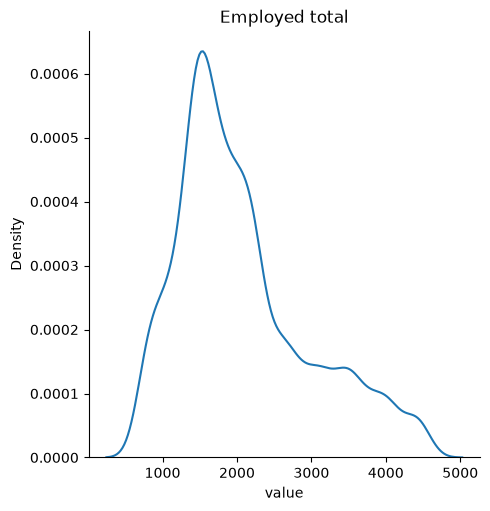

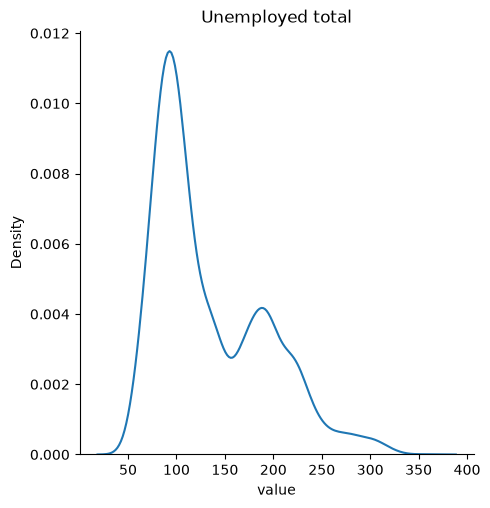

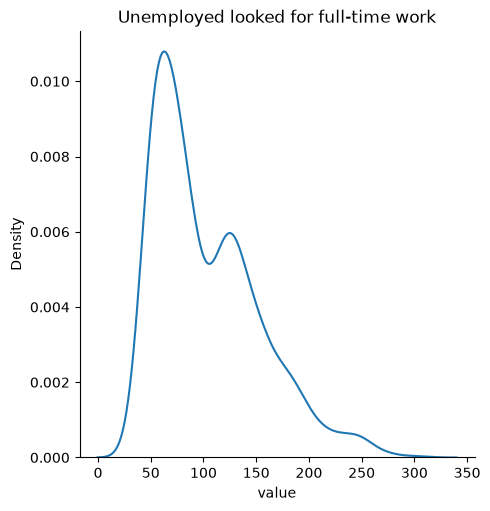

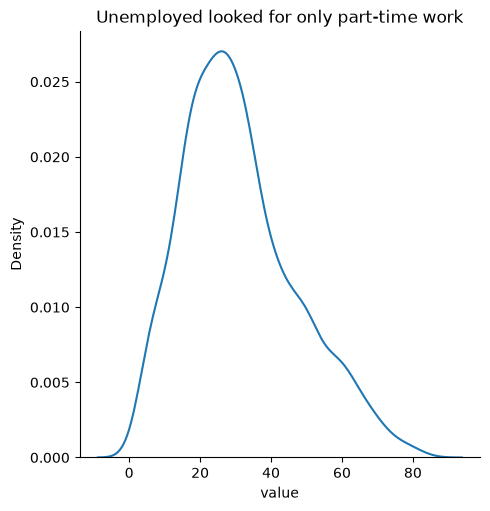

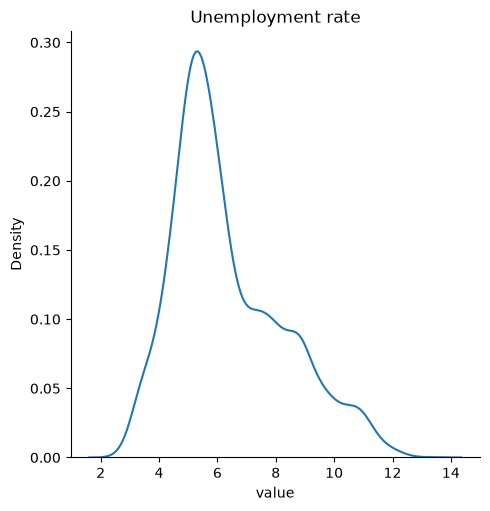

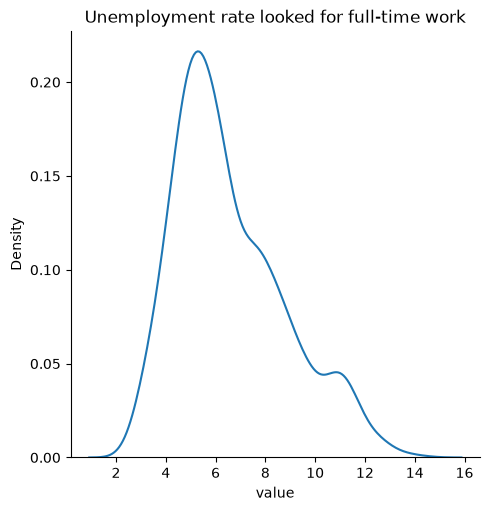

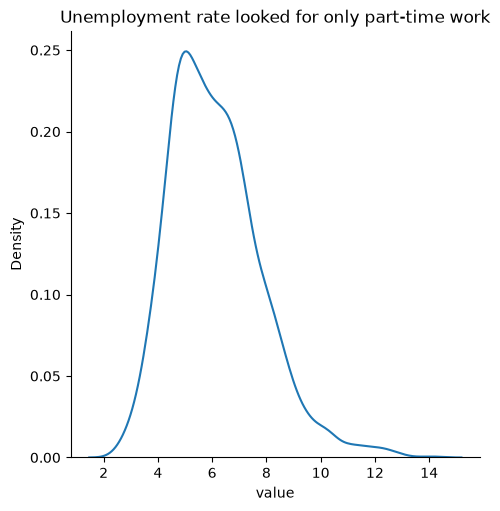

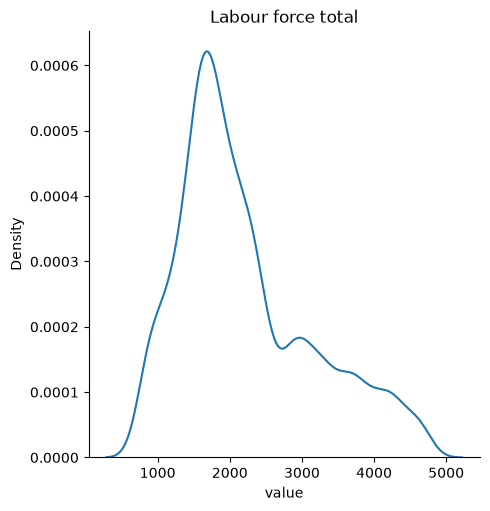

In [81]:
# data distribution
variables = categories_with_outliers_in_value
for v in variables:
    filtered_data=employment_status_new_south_wales_Original[employment_status_new_south_wales_Original['variable'] == v]
    g = sns.displot(filtered_data, x="value", kind="kde")
    g.set(title=v)
    display(g)
    print('')

summary: after differeciae the data by variables, the range of data become closer to each other. This shows that different variables has its own units and range which cause this issues.

**gender**

In [31]:
# range by gender:
analysis.value_range(employment_status_new_south_wales_Original, 'gender', 'value')

Persons:


'max: 7148.465001, min: 2.7641083'


Males:


'max: 3523.8420006, min: 1.9266846'


Females:


'max: 3624.6230004, min: 2.6344665'

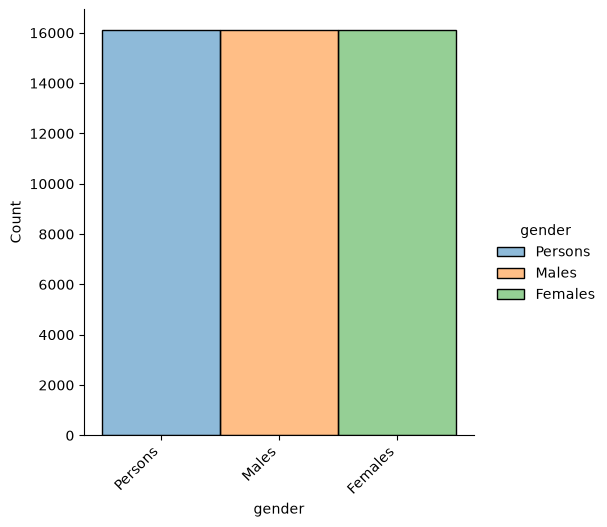

In [30]:
# how data distributed
g = sns.displot(
    employment_status_new_south_wales_Original, 
    x='gender', 
    hue='gender', 
    common_bins=False
)
# Rotate the x-axis labels for all subplots
g.set_xticklabels(rotation=45, ha='right')

In [87]:
#outlier
variables = employment_status_new_south_wales_Original['gender'].unique()
categories_with_outliers_in_value = []
for v in variables:
    print(v)
    filtered_data=employment_status_new_south_wales_Original[employment_status_new_south_wales_Original['gender'] == v]
    number = analysis.number_of_outliers(filtered_data, 'value')
    print('')
    if number != 0:
        categories_with_outliers_in_value.append(v)



print('')
print(f'folling variables have out liers: {categories_with_outliers_in_value}')

Persons
Lower bound: -3548.806566125, Upper bound: 6068.613895275
Number of outliers in 'value': 141

Males
Lower bound: -2117.9378057999998, Upper bound: 3706.5769662000002
Number of outliers in 'value': 0

Females
Lower bound: -1495.798393675, Upper bound: 2610.298398925
Number of outliers in 'value': 303


folling variables have out liers: ['Persons', 'Females']


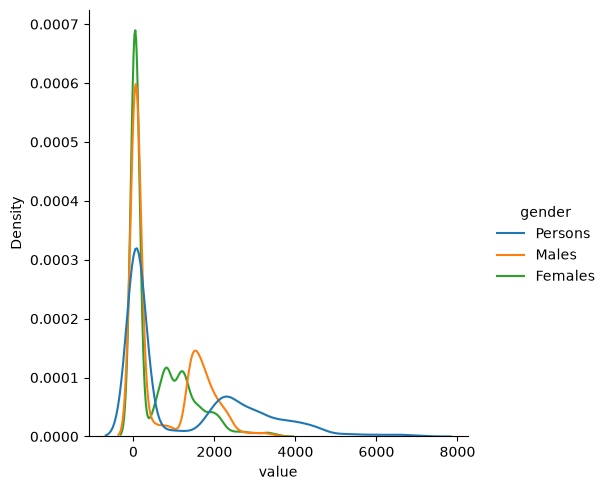

In [88]:
sns.displot(employment_status_new_south_wales_Original, x="value", hue="gender", kind="kde")

**series_type**

In [26]:
# range by series_type
analysis.value_range(employment_status_new_south_wales_Original, 'series_type', 'value')

Trend:


'max: 4691.4589695, min: 3.0760078'


Seasonally Adjusted:


'max: 4697.0340532, min: 2.6676361'


Original:


'max: 7148.465001, min: 1.9266846'

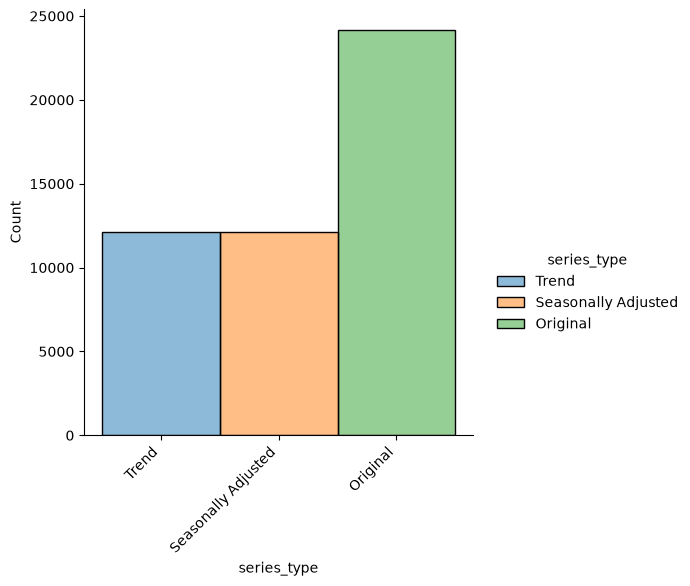

In [32]:
# how data distributed
g = sns.displot(
    employment_status_new_south_wales_Original, 
    x='series_type', 
    hue='series_type', 
    common_bins=False
)
# Rotate the x-axis labels for all subplots
g.set_xticklabels(rotation=45, ha='right')

In [ ]:
# Trend and seasonally adjusted has less data than original
# we can try to ceck if there is any relation ship between series_type and variable

##### **Why Trend and seasonally Adjusted has less data? which part is missing?**

In [89]:
o = set(employment_status_new_south_wales_Original[employment_status_new_south_wales_Original['series_type'] == 'Original']['variable'])
t = set(employment_status_new_south_wales_Original[employment_status_new_south_wales_Original['series_type'] == 'Trend']['variable'])
sa = set(employment_status_new_south_wales_Original[employment_status_new_south_wales_Original['series_type'] == 'Seasonally Adjusted']['variable'])
display(o, t, sa)

{'Civilian population aged 15 years and over',
 'Employed full-time',
 'Employed part-time',
 'Employed total',
 'Employment to population ratio',
 'Labour force total',
 'Not in the labour force (NILF',
 'Participation rate',
 'Unemployed looked for full-time work',
 'Unemployed looked for only part-time work',
 'Unemployed total',
 'Unemployment rate',
 'Unemployment rate looked for full-time work',
 'Unemployment rate looked for only part-time work'}

{'Employed full-time',
 'Employed total',
 'Employment to population ratio',
 'Labour force total',
 'Participation rate',
 'Unemployed total',
 'Unemployment rate'}

{'Employed full-time',
 'Employed total',
 'Employment to population ratio',
 'Labour force total',
 'Participation rate',
 'Unemployed total',
 'Unemployment rate'}

In [90]:
# check if variable in trend and seasonally adjusted has same value
print(f'trend and seasonally adjested has same value :{t == sa}')

trend and seasonally adjested has same value :True


In [91]:
# what are the values in original that is not in other categories in series type
print('These variales are only in original type')
print(o - t)

These variales are only in original type
{'Employed part-time', 'Unemployed looked for full-time work', 'Unemployed looked for only part-time work', 'Not in the labour force (NILF', 'Civilian population aged 15 years and over', 'Unemployment rate looked for full-time work', 'Unemployment rate looked for only part-time work'}


Summary:
some varibles are missing in Trend and seasonally Adjusted

##### **OutLiers**

In [42]:
#outlier
variables = employment_status_new_south_wales_Original['series_type'].unique()
categories_with_outliers_in_value = []
for v in variables:
    print(v)
    filtered_data=employment_status_new_south_wales_Original[employment_status_new_south_wales_Original['series_type'] == v]
    number = analysis.number_of_outliers(filtered_data, 'value')
    print('')
    if number != 0:
        categories_with_outliers_in_value.append(v)



print('')
print(f'folling variables have out liers: {categories_with_outliers_in_value}')

Trend
Lower bound: -2277.1930675625003, Upper bound: 3951.7108449375
Number of outliers in 'value': 211

Seasonally Adjusted
Lower bound: -2279.1224601125, Upper bound: 3954.7139261875
Number of outliers in 'value': 212

Original
Lower bound: -2052.578557625, Upper bound: 3497.084123375
Number of outliers in 'value': 1012


folling variables have out liers: ['Trend', 'Seasonally Adjusted', 'Original']


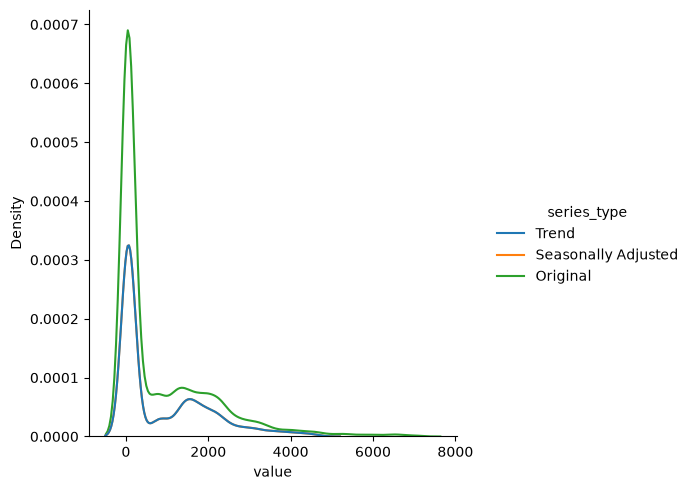

In [58]:
sns.displot(employment_status_new_south_wales_Original, x="value", hue="series_type", kind="kde")

Summary:
Overall, we have huge data range in this datasets, cause by the different unit in between variables. There are not much of outliers and there is no evident that shows any anomolies. Currently, we will keep the data as it is. 
Note: the structure of employmentstatus datasets are similar. Hence, we may observe similar phanominon. 

##### **Find Primary Key**

In [ ]:
# find primary key
columns = ['date', 'series_id']
is_not_unique = not employment_status_new_south_wales_Original[columns].duplicated().any()
print(f'this/these columns {columns} can use as primary: {is_not_unique}')

### B. EmploymentStatus_NorthernTerritory

In [80]:
employment_status_northern_territory_original= dataframes['employment_status_northern_territory_original'].copy()


#### Observe and Analyse the dataset

In [81]:
employment_status_northern_territory_original.head()

,date,series_id,state,variable,gender,series_type,value
0,1978-02-01,A84423335F,NorthernTerritory,Employed total,Persons,Seasonally Adjusted,41.624292
1,1978-03-01,A84423335F,NorthernTerritory,Employed total,Persons,Seasonally Adjusted,45.341661
2,1978-04-01,A84423335F,NorthernTerritory,Employed total,Persons,Seasonally Adjusted,44.021738
3,1978-05-01,A84423335F,NorthernTerritory,Employed total,Persons,Seasonally Adjusted,45.769913
4,1978-06-01,A84423335F,NorthernTerritory,Employed total,Persons,Seasonally Adjusted,42.605502


In [89]:
employment_status_northern_territory_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 12096 entries, 0 to 12095
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         12096 non-null  datetime64[us]
 1   series_id    12096 non-null  str           
 2   state        12096 non-null  str           
 3   variable     12096 non-null  str           
 4   gender       12096 non-null  str           
 5   series_type  12096 non-null  str           
 6   value        12096 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 1.5 MB


In [91]:
has_duplicates = employment_status_northern_territory_original.duplicated().any()
print(has_duplicates)

False


In [92]:
employment_status_northern_territory_original.describe()

,date,value
count,12096,12096.000000
mean,2002-01-15 09:30:00,47.953646
min,1978-02-01 00:00:00,0.366381
25%,1990-01-24 06:00:00,7.181921
50%,2002-01-16 12:00:00,54.696080
75%,2014-01-08 18:00:00,71.319271
max,2026-01-01 00:00:00,153.130609
std,NaN,34.384120


In [94]:
set(employment_status_northern_territory_original['series_type'])

{'Seasonally Adjusted'}

In [95]:
# find duplicate in each column
for one in employment_status_northern_territory_original.columns:
    individual_values = employment_status_northern_territory_original[one].is_unique
    print(f'{one}:{individual_values}')
    

date:False
series_id:False
state:False
variable:False
gender:False
series_type:False
value:True


**Find primary key**

In [101]:
# find primary key
columns = ['date', 'series_id']
is_not_unique = not employment_status_northern_territory_original[columns].duplicated().any()
print(f'this/these columns {columns} can use as primary: {is_not_unique}')

this/these columns ['date', 'series_id'] can becaome primary: True


### C. EmploymentStatus_Queensland

In [107]:
employment_status_queensland_original= dataframes['employment_status_queensland_original'].copy()

#### Observe and Analyse the dataset

In [109]:
employment_status_queensland_original.head()

,date,series_id,state,variable,gender,series_type,value
0,1978-02-01,A84423951K,Queensland,Employed total,Persons,Trend,872.764603
1,1978-03-01,A84423951K,Queensland,Employed total,Persons,Trend,872.336548
2,1978-04-01,A84423951K,Queensland,Employed total,Persons,Trend,872.096895
3,1978-05-01,A84423951K,Queensland,Employed total,Persons,Trend,871.916340
4,1978-06-01,A84423951K,Queensland,Employed total,Persons,Trend,872.089190


In [110]:
employment_status_queensland_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 48384 entries, 0 to 48383
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         48384 non-null  datetime64[us]
 1   series_id    48384 non-null  str           
 2   state        48384 non-null  str           
 3   variable     48384 non-null  str           
 4   gender       48384 non-null  str           
 5   series_type  48384 non-null  str           
 6   value        48384 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 5.3 MB


In [112]:
has_duplicates = employment_status_queensland_original.duplicated().any()
print(has_duplicates)

False


In [113]:
employment_status_queensland_original.describe()

,date,value
count,48384,48384.000000
mean,2002-01-15 09:30:00,493.326714
min,1978-02-01 00:00:00,0.950677
25%,1990-01-24 06:00:00,43.647983
50%,2002-01-16 12:00:00,74.687653
75%,2014-01-08 18:00:00,828.110374
max,2026-01-01 00:00:00,4707.950001
std,NaN,688.819395


In [114]:
set(employment_status_queensland_original['series_type'])

{'Original', 'Seasonally Adjusted', 'Trend'}

In [118]:
# find duplicate in each column
for one in employment_status_queensland_original.columns:
    individual_values = employment_status_queensland_original[one].is_unique
    print(f'{one}:{individual_values}')
    

date:False
series_id:False
state:False
variable:False
gender:False
series_type:False
value:False


**Find primary key**

In [122]:
# find primary key
columns = ['date', 'series_id']
is_not_unique = not employment_status_queensland_original[columns].duplicated().any()
print(f'this/these columns {columns} can use as primary: {is_not_unique}')

this/these columns ['date', 'series_id'] can use as primary: True


### D. EmploymentStatus_SouthAustralia

In [123]:
employment_status_south_australia_original= dataframes['employment_status_south_australia_original'].copy()

#### Observe and Analyse the dataset

In [124]:
employment_status_south_australia_original.head()

,date,series_id,state,variable,gender,series_type,value
0,1978-02-01,A84424035W,SouthAustralia,Employed total,Persons,Trend,555.233447
1,1978-03-01,A84424035W,SouthAustralia,Employed total,Persons,Trend,556.805668
2,1978-04-01,A84424035W,SouthAustralia,Employed total,Persons,Trend,558.167085
3,1978-05-01,A84424035W,SouthAustralia,Employed total,Persons,Trend,559.371365
4,1978-06-01,A84424035W,SouthAustralia,Employed total,Persons,Trend,560.089981


In [125]:
employment_status_south_australia_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 48384 entries, 0 to 48383
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         48384 non-null  datetime64[us]
 1   series_id    48384 non-null  str           
 2   state        48384 non-null  str           
 3   variable     48384 non-null  str           
 4   gender       48384 non-null  str           
 5   series_type  48384 non-null  str           
 6   value        48384 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 5.5 MB


In [126]:
has_duplicates = employment_status_south_australia_original.duplicated().any()
print(has_duplicates)

False


In [127]:
employment_status_south_australia_original.describe()

,date,value
count,48384,48384.000000
mean,2002-01-15 09:30:00,207.623059
min,1978-02-01 00:00:00,0.535085
25%,1990-01-24 06:00:00,21.846715
50%,2002-01-16 12:00:00,63.215336
75%,2014-01-08 18:00:00,360.129444
max,2026-01-01 00:00:00,1600.897000
std,NaN,258.348187


In [128]:
set(employment_status_south_australia_original['series_type'])

{'Original', 'Seasonally Adjusted', 'Trend'}

In [129]:
# find duplicate in each column
for one in employment_status_south_australia_original.columns:
    individual_values = employment_status_south_australia_original[one].is_unique
    print(f'{one}:{individual_values}')
    

date:False
series_id:False
state:False
variable:False
gender:False
series_type:False
value:True


**Find primary key**

In [151]:
# find primary key
columns = ['date', 'series_id']
is_not_unique = not employment_status_south_australia_original[columns].duplicated().any()
print(f'this/these columns {columns} can use as primary: {is_not_unique}')

this/these columns ['date', 'series_id'] can use as primary: True


Because 'date' and 'series_id' can be unique while combine, we use them as primary key.

### E. EmploymentStatus_Tasmania

In [132]:
employment_status_tasmania_original= dataframes['employment_status_tasmania_original'].copy()

#### Observe and Analyse the dataset

In [133]:
employment_status_tasmania_original.head()

,date,series_id,state,variable,gender,series_type,value
0,1978-02-01,A84423965X,Tasmania,Employed total,Persons,Trend,165.523304
1,1978-03-01,A84423965X,Tasmania,Employed total,Persons,Trend,165.445856
2,1978-04-01,A84423965X,Tasmania,Employed total,Persons,Trend,165.393696
3,1978-05-01,A84423965X,Tasmania,Employed total,Persons,Trend,165.384243
4,1978-06-01,A84423965X,Tasmania,Employed total,Persons,Trend,165.466020


In [134]:
employment_status_tasmania_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 48384 entries, 0 to 48383
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         48384 non-null  datetime64[us]
 1   series_id    48384 non-null  str           
 2   state        48384 non-null  str           
 3   variable     48384 non-null  str           
 4   gender       48384 non-null  str           
 5   series_type  48384 non-null  str           
 6   value        48384 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 5.2 MB


In [145]:
# find duplicate of each observation
has_duplicates = employment_status_tasmania_original.duplicated().any()
print(has_duplicates)

False


In [138]:
# find duplicate in each column
for one in employment_status_tasmania_original.columns:
    individual_values = employment_status_tasmania_original[one].is_unique
    print(f'{one}:{individual_values}')

date:False
series_id:False
state:False
variable:False
gender:False
series_type:False
value:False


In [136]:
employment_status_tasmania_original.describe()

,date,value
count,48384,48384.000000
mean,2002-01-15 09:30:00,72.635624
min,1978-02-01 00:00:00,0.000000
25%,1990-01-24 06:00:00,9.677586
50%,2002-01-16 12:00:00,56.050905
75%,2014-01-08 18:00:00,110.279704
max,2026-01-01 00:00:00,485.717000
std,NaN,74.690607


In [137]:
set(employment_status_tasmania_original['series_type'])

{'Original', 'Seasonally Adjusted', 'Trend'}

**Find primary key**

In [139]:
# find primary key
columns = ['date', 'series_id']
is_not_unique = not employment_status_tasmania_original[columns].duplicated().any()
print(f'this/these columns {columns} can use as primary: {is_not_unique}')

this/these columns ['date', 'series_id'] can becaome primary: True


### F. EmploymentStatus_Victoria

In [142]:
employment_status_victoria_original= dataframes['employment_status_victoria_original'].copy()

#### Observe and Analyse the dataset

In [143]:
employment_status_victoria_original.head()

,date,series_id,state,variable,gender,series_type,value
0,1978-02-01,A84424021J,Victoria,Employed total,Persons,Trend,1638.123654
1,1978-03-01,A84424021J,Victoria,Employed total,Persons,Trend,1642.785934
2,1978-04-01,A84424021J,Victoria,Employed total,Persons,Trend,1646.610122
3,1978-05-01,A84424021J,Victoria,Employed total,Persons,Trend,1649.552186
4,1978-06-01,A84424021J,Victoria,Employed total,Persons,Trend,1650.880870


In [144]:
employment_status_victoria_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 48384 entries, 0 to 48383
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         48384 non-null  datetime64[us]
 1   series_id    48384 non-null  str           
 2   state        48384 non-null  str           
 3   variable     48384 non-null  str           
 4   gender       48384 non-null  str           
 5   series_type  48384 non-null  str           
 6   value        48384 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 5.2 MB


In [146]:
# find duplicate of each observation
has_duplicates = employment_status_victoria_original.duplicated().any()
print(has_duplicates)

False


In [147]:
# find duplicate in each column
for one in employment_status_victoria_original.columns:
    individual_values = employment_status_victoria_original[one].is_unique
    print(f'{one}:{individual_values}')

date:False
series_id:False
state:False
variable:False
gender:False
series_type:False
value:True


In [148]:
employment_status_victoria_original.describe()

,date,value
count,48384,48384.000000
mean,2002-01-15 09:30:00,666.143369
min,1978-02-01 00:00:00,2.217902
25%,1990-01-24 06:00:00,50.910683
50%,2002-01-16 12:00:00,85.343630
75%,2014-01-08 18:00:00,1175.006770
max,2026-01-01 00:00:00,5909.417001
std,NaN,912.176012


In [149]:
set(employment_status_victoria_original['series_type'])

{'Original', 'Seasonally Adjusted', 'Trend'}

**Find primary key**

In [152]:
# find primary key
columns = ['date', 'series_id']
is_not_unique = not employment_status_victoria_original[columns].duplicated().any()
print(f'this/these columns {columns} can use as primary: {is_not_unique}')

this/these columns ['date', 'series_id'] can use as primary: True


### G. EmploymentStatus_WesternAuds

In [153]:
employment_status_western_auds_original= dataframes['employment_status_western_auds_original'].copy()

#### Observe and Analyse the dataset

In [154]:
employment_status_western_auds_original.head()

,date,series_id,state,variable,gender,series_type,value
0,1978-02-01,A84423993J,WesternAuds,Employed total,Persons,Trend,529.789199
1,1978-03-01,A84423993J,WesternAuds,Employed total,Persons,Trend,529.527348
2,1978-04-01,A84423993J,WesternAuds,Employed total,Persons,Trend,529.099262
3,1978-05-01,A84423993J,WesternAuds,Employed total,Persons,Trend,528.615678
4,1978-06-01,A84423993J,WesternAuds,Employed total,Persons,Trend,527.969603


In [155]:
employment_status_western_auds_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 48384 entries, 0 to 48383
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         48384 non-null  datetime64[us]
 1   series_id    48384 non-null  str           
 2   state        48384 non-null  str           
 3   variable     48384 non-null  str           
 4   gender       48384 non-null  str           
 5   series_type  48384 non-null  str           
 6   value        48384 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 5.4 MB


In [158]:
# find duplicate of each observation
has_duplicates = employment_status_western_auds_original.duplicated().any()
print(has_duplicates)

False


In [159]:
# find duplicate in each column
for one in employment_status_western_auds_original.columns:
    individual_values = employment_status_western_auds_original[one].is_unique
    print(f'{one}:{individual_values}')

date:False
series_id:False
state:False
variable:False
gender:False
series_type:False
value:True


In [160]:
employment_status_western_auds_original.describe()

,date,value
count,48384,48384.000000
mean,2002-01-15 09:30:00,276.571713
min,1978-02-01 00:00:00,0.695100
25%,1990-01-24 06:00:00,24.339117
50%,2002-01-16 12:00:00,69.460408
75%,2014-01-08 18:00:00,455.262243
max,2026-01-01 00:00:00,2533.663000
std,NaN,371.118317


In [161]:
set(employment_status_western_auds_original['series_type'])

{'Original', 'Seasonally Adjusted', 'Trend'}

**Find primary key**

In [162]:
# find primary key
columns = ['date', 'series_id']
is_not_unique = not employment_status_western_auds_original[columns].duplicated().any()
print(f'this/these columns {columns} can use as primary: {is_not_unique}')

this/these columns ['date', 'series_id'] can use as primary: True


### Summary of employment status!

**Missing value**:\
There is no missing value among datasets.

**Data structure among emplyment status datasets**:\
Employment_status_northern_territory_original only have 'Trend' series type data, so Northern Terrirory has only 12096 observations. The rest datasets has observation of 48383 with three series type, 'Original', 'Seasonally Adjusted', 'Trend'.

**Distributions**:\
Since the variables of the datasets are in differnt unit, the value has a huge range in different dataset. Over all, most of the values in between xxx to xxx.

**Outliers**:\
The outliers are normal data. We will keep them as it is in this stage.

### ERP_Quarterly

In [283]:
erp_quarterly_original= dataframes['erp_quarterly_original'].copy()

#### Observe and Analyse the dataset

##### **Overall**


In [120]:
erp_quarterly_original.head()

,measure,sex,age,region,time_period,obs_value
0,ERP Percentage Change Over Previous Year,Females,24,Western Australia,1981-Q3,NaN
1,ERP Percentage Change Over Previous Year,Females,24,Western Australia,1981-Q4,NaN
2,ERP Percentage Change Over Previous Year,Females,24,Western Australia,1982-Q1,NaN
3,ERP Percentage Change Over Previous Year,Females,24,Western Australia,1982-Q2,NaN
4,ERP Percentage Change Over Previous Year,Females,24,Western Australia,1982-Q3,3.02


In [121]:
erp_quarterly_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 1662120 entries, 0 to 1662119
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   measure      1662120 non-null  str    
 1   sex          1662120 non-null  str    
 2   age          1662120 non-null  str    
 3   region       1662120 non-null  str    
 4   time_period  1662120 non-null  str    
 5   obs_value    1635665 non-null  float64
dtypes: float64(1), str(5)
memory usage: 175.4 MB


there are many missing values in obs_value. We need to futher investigate to identify the category of missing values.

In [122]:
# find duplicate of each observation
has_duplicates = erp_quarterly_original.duplicated().any()
print(has_duplicates)

False


In [123]:
# find duplicate in each column
for one in erp_quarterly_original.columns:
    individual_values = erp_quarterly_original[one].is_unique
    print(f'{one}:{individual_values}')

measure:False
sex:False
age:False
region:False
time_period:False
obs_value:False


In [124]:
erp_quarterly_original.describe()

,obs_value
count,1.635665e+06
mean,2.573648e+04
std,2.940259e+05
min,-8.467300e+04
25%,1.430000e+00
50%,8.000000e+01
75%,3.816000e+03
max,2.712241e+07


#### Convert data type

In [284]:
erp_quarterly_original['age'].unique()

<ArrowStringArray>
[   '24',    '90',    '75',    '51',     '3',    '83',    '73',    '56',
    '29',    '35',
 ...
    '58',    '54',    '21',    '14',    '19',    '70',    '12',    '44',
    '92', '65-69']
Length: 120, dtype: str

age has number and age groups, so we will keep it as str for now

In [288]:
# convert time_period from str to pandas quarterly period
# erp_quarterly_original["date_type"] = pd.dt.to_timestamp(
#     erp_quarterly_original["time_period"],
#     freq="Q"
# )
erp_quarterly_original["date_type"] = (
    pd.PeriodIndex(erp_quarterly_original["time_period"], freq="Q")
    .to_timestamp()
)

In [289]:
# data types
erp_quarterly_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 1662120 entries, 0 to 1662119
Data columns (total 7 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   measure      1662120 non-null  str           
 1   sex          1662120 non-null  str           
 2   age          1662120 non-null  str           
 3   region       1662120 non-null  str           
 4   time_period  1662120 non-null  str           
 5   obs_value    1635665 non-null  float64       
 6   date_type    1662120 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 188.1 MB


#### Missing value further investigation: obs_value

##### **time period vs  obs_value**

In [137]:
# get the count of time_period when the value is missing
missing_value = erp_quarterly_original.copy()

tp_missing_value = pd.DataFrame(
    erp_quarterly_original[
        erp_quarterly_original['obs_value'].isnull()
    ][['time_period']].value_counts()
).reset_index()

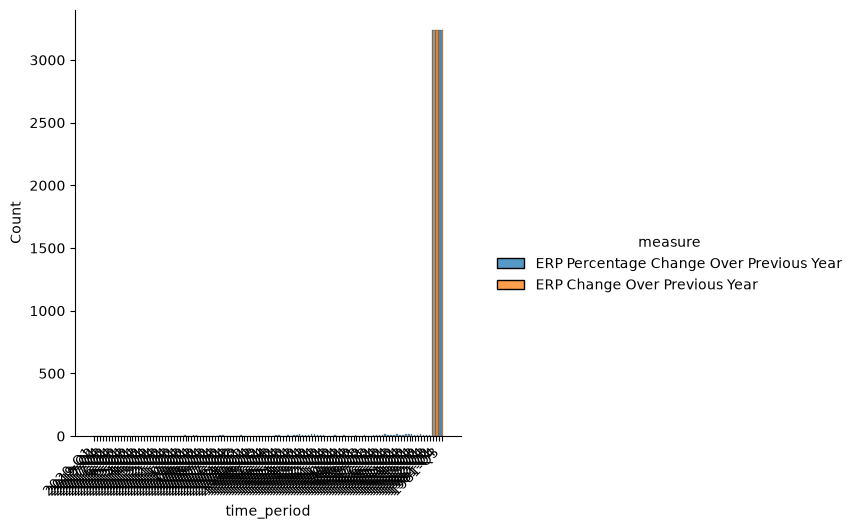

In [148]:
# distribution of all missing values that group by measure
use_data = tp_missing_value

data_require_visual = erp_quarterly_original[
    erp_quarterly_original['obs_value'].isnull()
    & erp_quarterly_original['time_period'].isin(use_data['time_period'])
].sort_values(by='time_period', ascending=False)

g = sns.displot(
    data_require_visual, 
    x='time_period', 
    kind='hist', 
    hue='measure', 
    multiple='dodge'
)
g.set_xticklabels(rotation=45, ha='right')

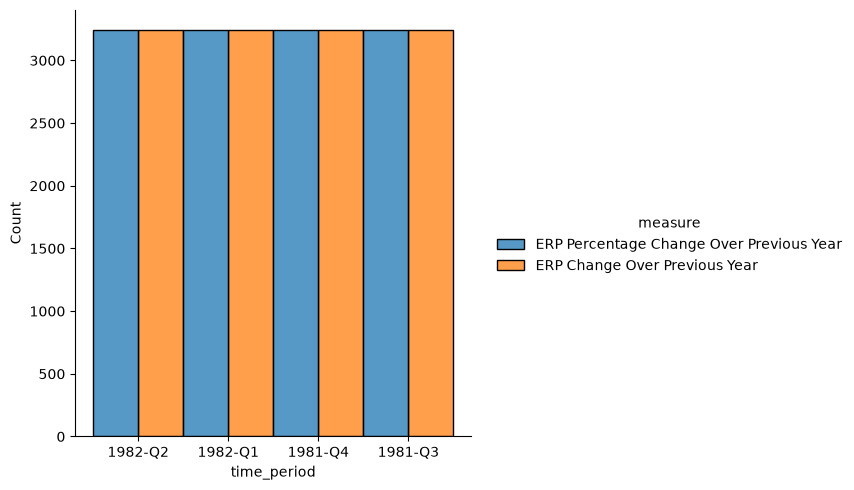

In [139]:
# filter out the observation is not in the max value (==6480)
filtered = tp_missing_value[
    tp_missing_value['count'] == tp_missing_value['count'].max()
]

use_data = filtered

missing_count_at_max = erp_quarterly_original[
    erp_quarterly_original['obs_value'].isnull()
    & erp_quarterly_original['time_period'].isin(use_data['time_period'])
].sort_values(by='time_period', ascending=False)

sns.displot(
    missing_count_at_max, 
    x='time_period', 
    kind='hist', 
    hue='measure', 
    multiple='dodge'
)

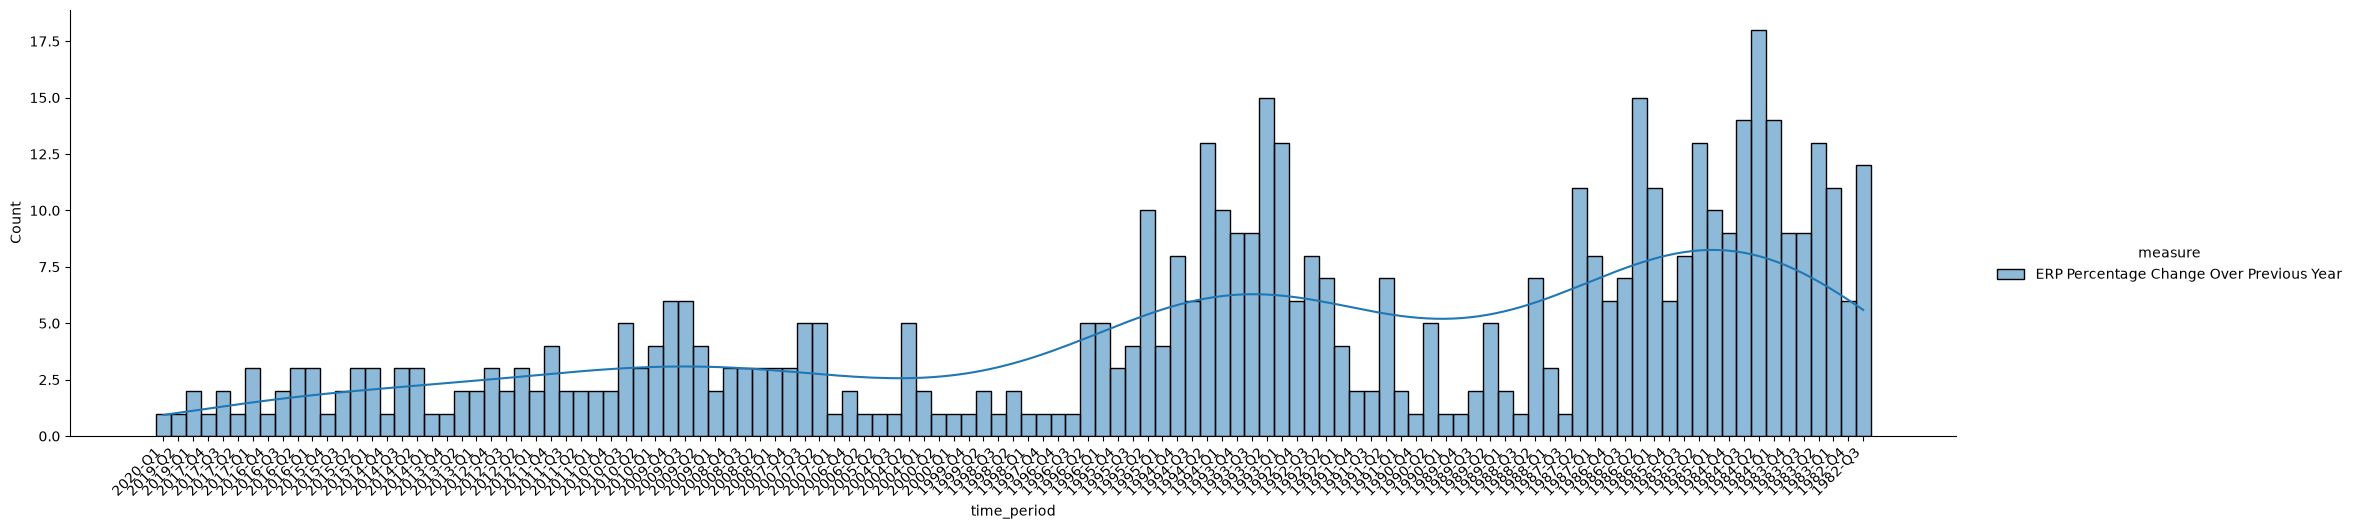

In [235]:
# filter out the time period that has max amount of count (<6480)
filtered = tp_missing_value[
    tp_missing_value['count'] < tp_missing_value['count'].max()
]

use_data = filtered

# check the missing value in each time period
missing_less_than_max = erp_quarterly_original[
    erp_quarterly_original['obs_value'].isnull()
    & erp_quarterly_original['time_period'].isin(use_data['time_period'])
].sort_values(by='time_period', ascending=False)

g = sns.displot(
    missing_less_than_max, 
    x='time_period', 
    kind='hist', 
    kde=True,
    hue='measure', 
    multiple='dodge',
    aspect=4
)
g.set_xticklabels(rotation=45, ha='right')

In [142]:
# find how many of percent of missing values are in the max count of missing obs_value
timeperiod_max_missing_count = tp_missing_value[
    tp_missing_value['count'] == tp_missing_value['count'].max()
]['time_period']

for t in timeperiod_max_missing_count:
    with_null = erp_quarterly_original[
        erp_quarterly_original['time_period'] == t
    ].shape[0]
    
    nulls = erp_quarterly_original[
        erp_quarterly_original['obs_value'].isnull()
        & (erp_quarterly_original['time_period'] == t)
    ].shape[0]

    missing_percentage = nulls/with_null*100
    
    print(f'time period:{t}: has {missing_percentage}% of observation missing. Has more than 20% of data is missing: {missing_percentage > 20}')
    print('')

time period:1981-Q3: has 66.66666666666666% of observation missing. Has more than 20% of data is missing: True

time period:1981-Q4: has 66.66666666666666% of observation missing. Has more than 20% of data is missing: True

time period:1982-Q1: has 66.66666666666666% of observation missing. Has more than 20% of data is missing: True

time period:1982-Q2: has 66.66666666666666% of observation missing. Has more than 20% of data is missing: True



##### **check the relationship of categories variables with values**

We wannage check the values that is not in those time period with max missing values.

In [153]:
# check all categories that has missing value
print(f'columns: {missing_less_than_max.columns}')
for c in missing_less_than_max.columns:
    columns = c
    unique_value = missing_less_than_max[columns].unique()
    print(f'{c}:')
    print(f'{unique_value}')
    print('')

columns: Index(['measure', 'sex', 'age', 'region', 'time_period', 'obs_value'], dtype='str')
measure:
<ArrowStringArray>
['ERP Percentage Change Over Previous Year']
Length: 1, dtype: str

sex:
<ArrowStringArray>
['Males', 'Females', 'Persons']
Length: 3, dtype: str

age:
<ArrowStringArray>
['100',  '99',  '98',  '97',  '96',  '95',  '94',  '90',  '93',  '85',  '92',
  '91',  '87',  '88',  '86']
Length: 15, dtype: str

region:
<ArrowStringArray>
[          'Northern Territory', 'Australian Capital Territory',
                     'Tasmania',              'South Australia',
            'Western Australia']
Length: 5, dtype: str

time_period:
<ArrowStringArray>
['2020-Q1', '2019-Q2', '2019-Q1', '2017-Q4', '2017-Q3', '2017-Q2', '2017-Q1',
 '2016-Q4', '2016-Q3', '2016-Q2',
 ...
 '1984-Q4', '1984-Q3', '1984-Q2', '1984-Q1', '1983-Q4', '1983-Q3', '1983-Q2',
 '1983-Q1', '1982-Q4', '1982-Q3']
Length: 115, dtype: str

obs_value:
[nan]



**summary：**‘ERP Percentage Change Over Previous Year' is the only categories that has missing values, so 'ERP Change Over Previous Year' only has missing values in 1981-Q3, 1981-Q4, 1982-Q1 and 1982-Q2, these four periods. Age has a clear range, that missing values are in between 86 to 100 years old. There are 5 region have missing values, which require further investigation. There is no clear pattern in sex and time periods.

##### **age vs obs_value**

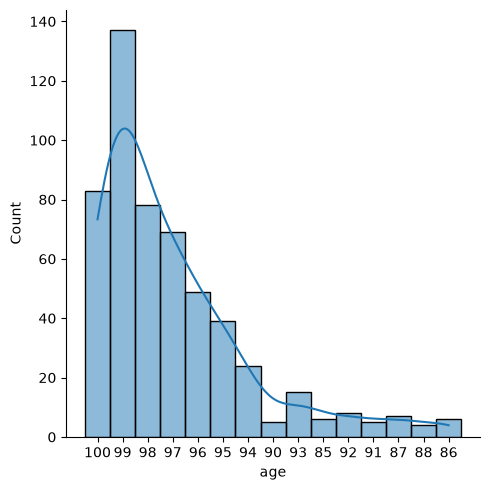

In [164]:
# filter out the time period that has max amount of count (<6480)
filtered = tp_missing_value[
    tp_missing_value['count'] < tp_missing_value['count'].max()
]

use_data = filtered

# check the missing values in each age
missing_less_than_max = erp_quarterly_original[
    erp_quarterly_original['obs_value'].isnull()
    & erp_quarterly_original['time_period'].isin(use_data['time_period'])
].sort_values(by='time_period', ascending=False)

g = sns.displot(
    missing_less_than_max, 
    x='age', 
    kind='hist', 
    kde=True
)

**summary:** \
The rest of missing values only happend at groups of age that are older than 86, and the pick is at the age of 99, more than 120 of obervation are nulls. Since the project is to analyse the potential of laber force, the elders data is not that important than the mid age labor. In Australia the Age Pension age is 67. We can drop the data over 70. 


##### **region vs obs_value**

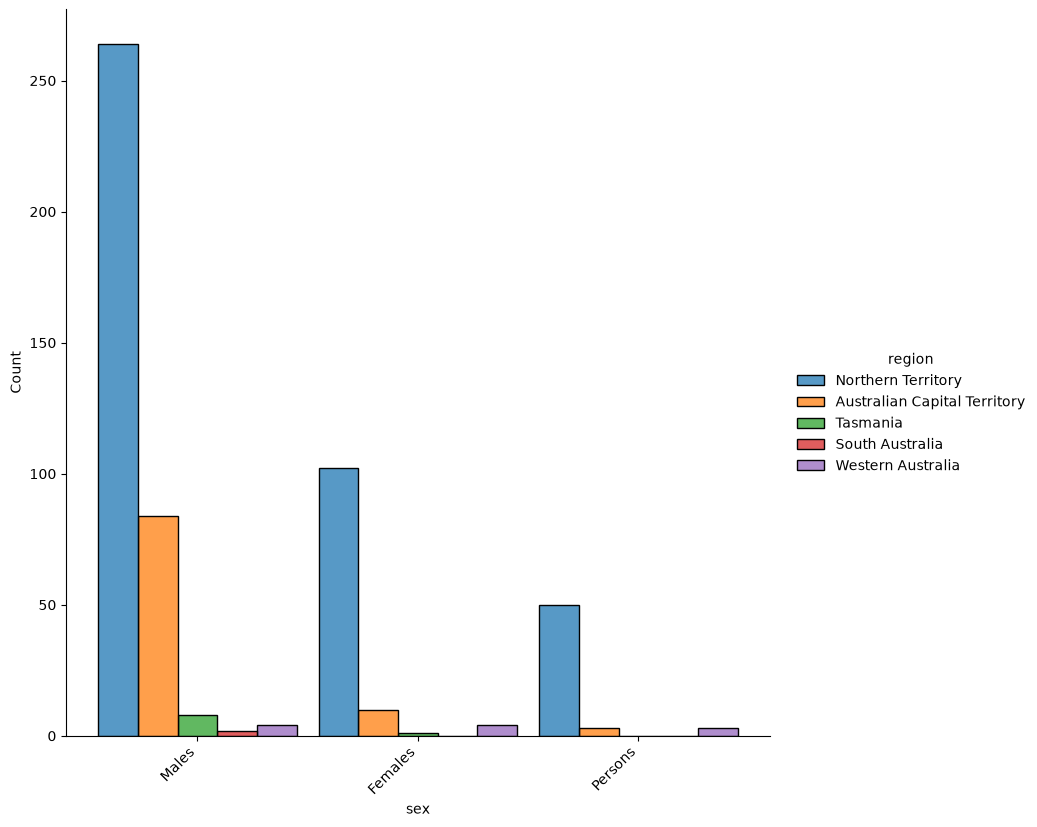

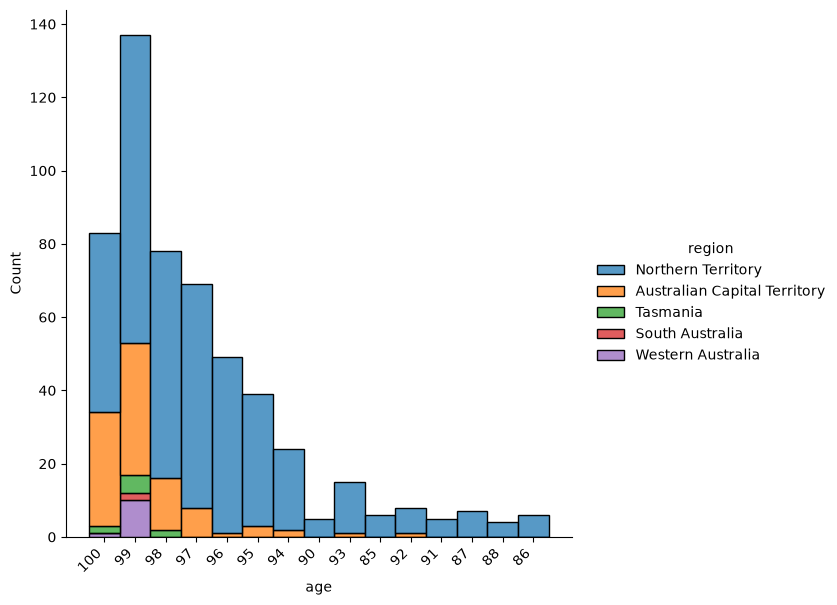

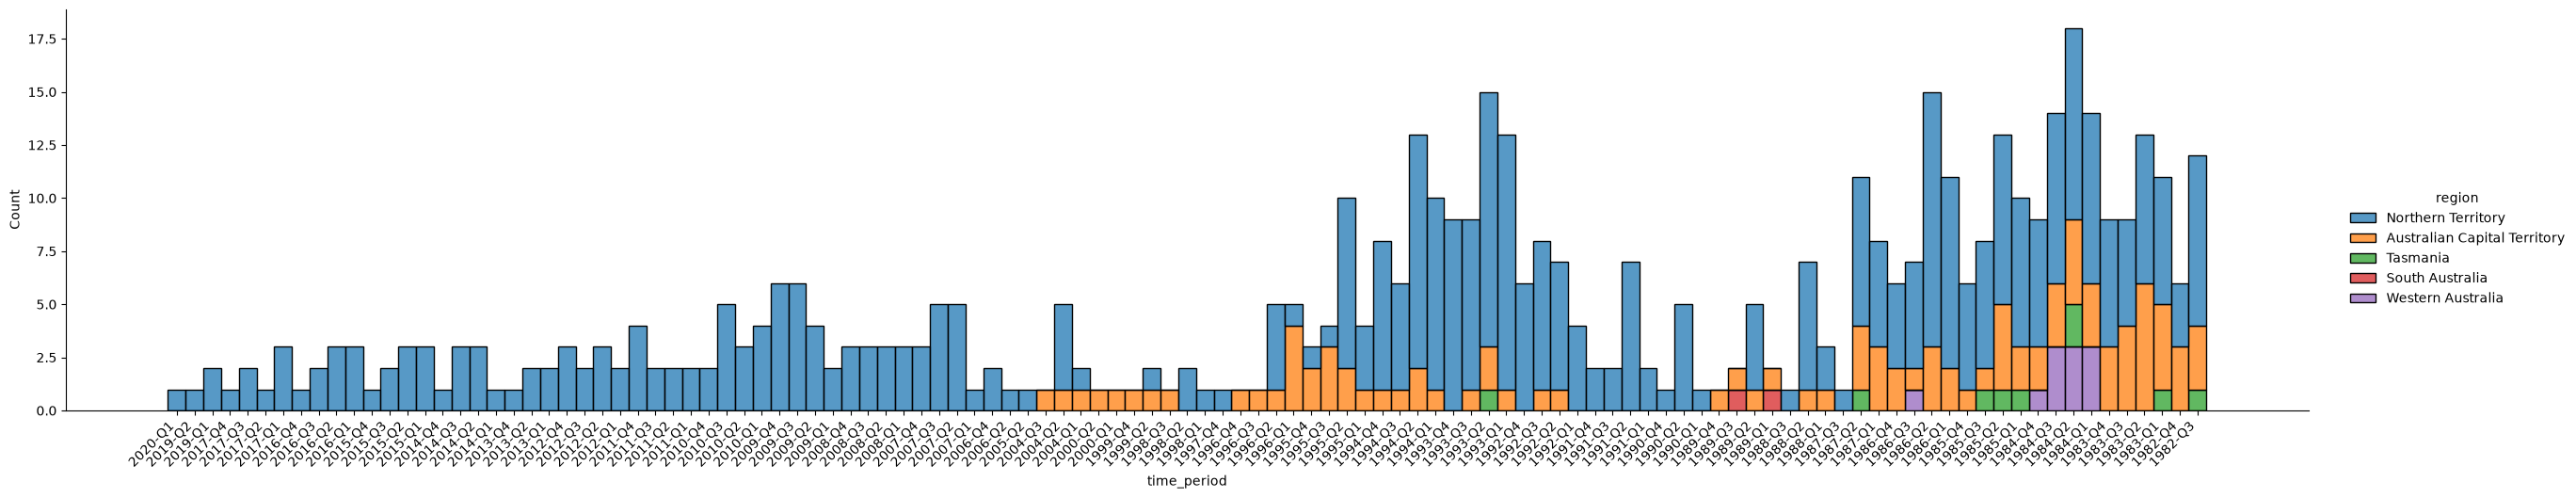

In [233]:
# filter out the time period that has max amount of count (<6480)
filtered = tp_missing_value[
    tp_missing_value['count'] < tp_missing_value['count'].max()
]

use_data = filtered

# check the missing values in each age
missing_less_than_max = erp_quarterly_original[
    erp_quarterly_original['obs_value'].isnull()
    & erp_quarterly_original['time_period'].isin(use_data['time_period'])
].sort_values(by='time_period', ascending=False)

#sex vs region
g = sns.displot(
    missing_less_than_max, 
    x='sex', 
    kind='hist', 
    hue='region',
    multiple="dodge",
    height=8,
    shrink=0.9,
    discrete=True
)
# Rotate the x-axis labels for all subplots
g.set_xticklabels(rotation=45, ha='right')

#age vs region
g = sns.displot(
    missing_less_than_max, 
    x='age', 
    kind='hist', 
    hue='region',
    multiple="stack",
    height=6
)
# Rotate the x-axis labels for all subplots
g.set_xticklabels(rotation=45, ha='right')

#time_period vs region
g = sns.displot(
    missing_less_than_max, 
    x='time_period', 
    kind='hist', 
    hue='region',
    multiple="stack",
    aspect=5
)
# Rotate the x-axis labels for all subplots
g.set_xticklabels(rotation=45, ha='right')

Summary:\
Northern Territory - \
Overall it has missing values in every categories that contains has nulls.\
sex vs region: It miss most of the data regarding male and seconly female than the least in persons. \
age vs region: It has missing values in every ages that has missing values, which in some age categories, such as 86 Northern Territory is the only region contain missing values. Most of the missing values are after 90 years old..\
time_period vs region: It has missing values in most of time periods, and more data is missing in the later time. Most of missing data is in two periods, from 1982 to 1988 and 1996 to 1991.\
missing type: MAR\
\
ACT -\
Overall it has similar patterns as Northern Territory but less missing values.\
sex vs region: It miss most of the data regarding male and only a few in female and persons is missing. \
age vs region: It only has missing values after 90 year olds. It has the most amount of missin data in 99-year-old.\
time_period vs region: The missing values can be plit into three groups, between 1998 and 2004, 1992 and 1996, and from 1982 to 1989.\
missing type: MAR\
\
Tasmania - \
Overall there is not much of missing values, but we can see some clear patterns when compare with sex and age.\
sex vs region: It does have missing values in persons. Most of the missing values are contain under male and only few missing values  \
age vs region: The missing values are under three ages, 98, 99, and 100.\
time_period vs region: Most of the missing values are in the 80s, and only 1993-Q2 contains missing values in the 90s.\
missing type: MAR\
\
South Australia -\
Overall it has the least missing value among all other regions.\
sex vs region: It only has a few missing values in male.\
age vs region: missing values are only in 99-year-old groups.\
time_period vs region: only Q3 and Q1 in 1989 have missing values.\
missing type: MAR\
\
Western Australia -\
Overall the missing data is in the age of 99 and in the year of 1984.\
sex vs region: the missing value in males, females and persons are almost the same.\
age vs region: The missing values are under three ages 99, and 100.\
time_period vs region: the whole year of 1984 contains the missing values, and a few in 1986-Q3.\
missing type: MAR


#### Statistic analysis of obs_values

In [290]:
erp_quarterly_original.head()

,measure,sex,age,region,time_period,obs_value,date_type
0,ERP Percentage Change Over Previous Year,Females,24,Western Australia,1981-Q3,NaN,1981-07-01
1,ERP Percentage Change Over Previous Year,Females,24,Western Australia,1981-Q4,NaN,1981-10-01
2,ERP Percentage Change Over Previous Year,Females,24,Western Australia,1982-Q1,NaN,1982-01-01
3,ERP Percentage Change Over Previous Year,Females,24,Western Australia,1982-Q2,NaN,1982-04-01
4,ERP Percentage Change Over Previous Year,Females,24,Western Australia,1982-Q3,3.02,1982-07-01


In [243]:
columns=['measure', 'sex', 'region']
for c in columns:
    results=erp_quarterly_original[c].unique()
    display(results)

<ArrowStringArray>
['ERP Percentage Change Over Previous Year',
            'Estimated Resident Population',
            'ERP Change Over Previous Year']
Length: 3, dtype: str

<ArrowStringArray>
['Females', 'Persons', 'Males']
Length: 3, dtype: str

<ArrowStringArray>
[           'Western Australia',              'South Australia',
 'Australian Capital Territory',           'Northern Territory',
                   'Queensland',                    'Australia',
                     'Tasmania',                     'Victoria',
              'New South Wales']
Length: 9, dtype: str

In [291]:
percentage_change = erp_quarterly_original[erp_quarterly_original['measure'] == 'ERP Percentage Change Over Previous Year']
change = erp_quarterly_original[erp_quarterly_original['measure'] == 'ERP Change Over Previous Year']
resident_population = erp_quarterly_original[erp_quarterly_original['measure'] == 'Estimated Resident Population']

In [280]:
print('ERP Percentage Change Over Previous Year')
display(percentage_change.describe())
print('ERP Change Over Previous Year')
display(change.describe())
print('Estimated Resident Population')
display(resident_population.describe())

ERP Percentage Change Over Previous Year


,obs_value
count,540545.000000
mean,2.665616
std,15.024309
min,-100.000000
25%,-0.200000
50%,1.640000
75%,3.890000
max,2600.000000


ERP Change Over Previous Year


,obs_value
count,541080.000000
mean,1046.902240
std,7796.725679
min,-84673.000000
25%,-6.000000
50%,96.000000
75%,624.000000
max,667366.000000


Estimated Resident Population


,obs_value
count,5.540400e+05
mean,7.495552e+04
std,5.015005e+05
min,0.000000e+00
25%,2.758000e+03
50%,1.263900e+04
75%,4.514400e+04
max,2.712241e+07


Based on min-max, we can not tell if there is unual data.

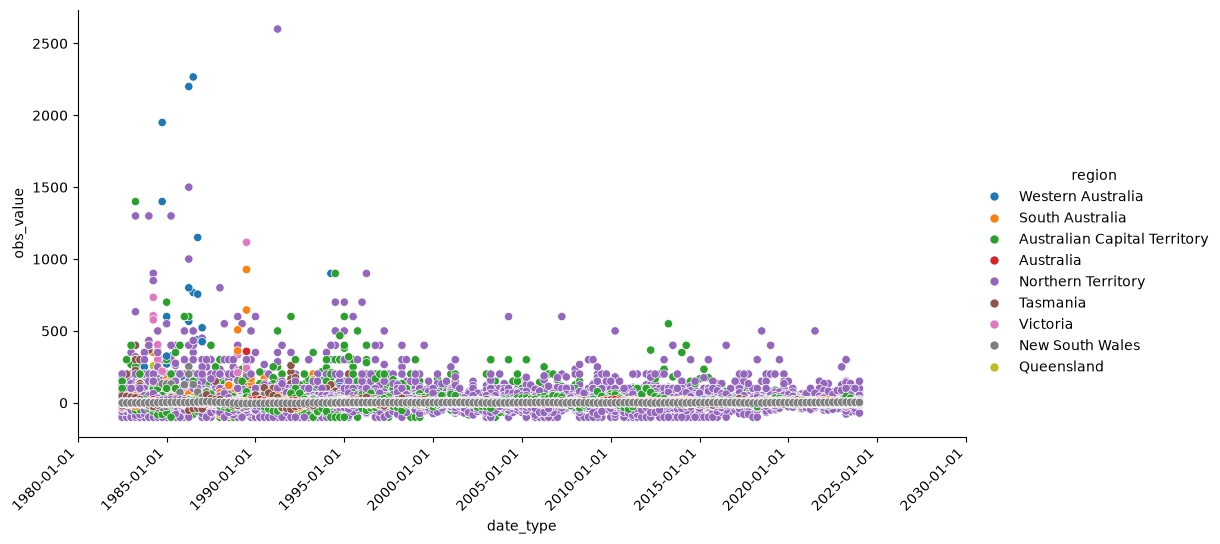

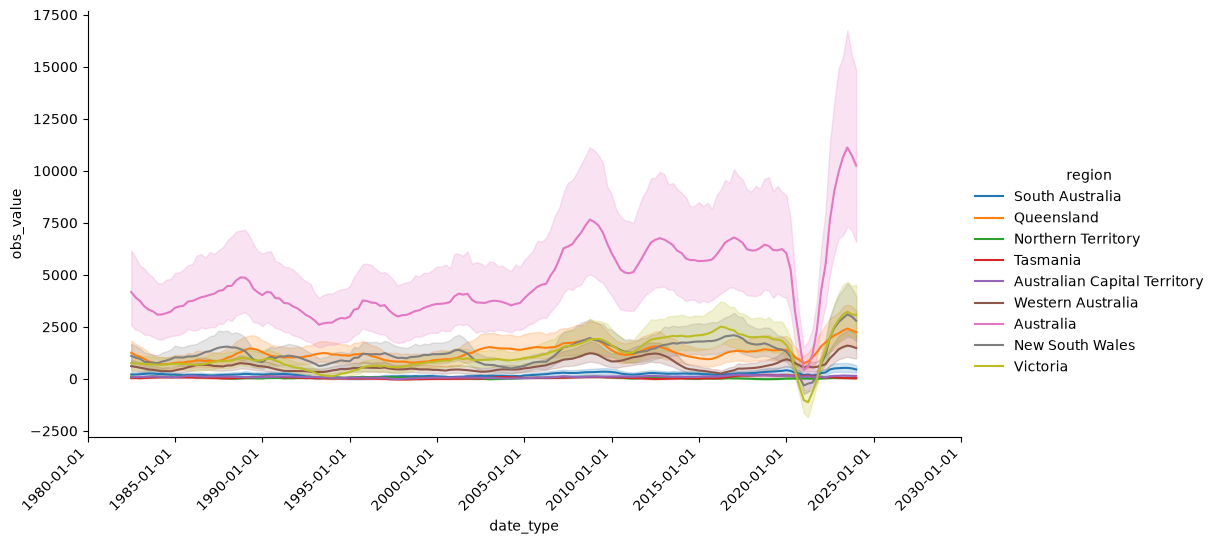

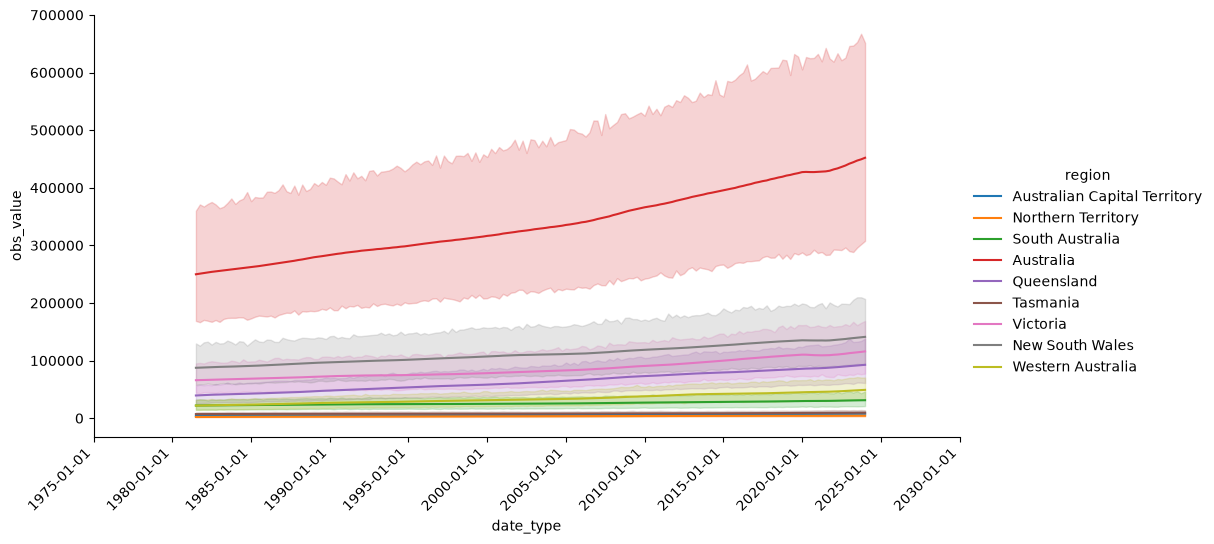

In [319]:
# percentage_change
# use dataset
dataset = percentage_change
#draft
resident_population_g = sns.relplot(
    data= dataset,
    x="date_type", 
    y="obs_value",
    hue='region',
    aspect=2
)
# Rotate the x-axis labels for all subplots
resident_population_g.set_xticklabels(rotation=45, ha='right')
#display
display(resident_population_g)

# change
# use dataset
dataset = change
#draft
resident_population_g = sns.relplot(
    data= dataset,
    x="date_type", 
    y="obs_value",
    hue='region',
    kind="line",
    aspect=2
)
# Rotate the x-axis labels for all subplots
resident_population_g.set_xticklabels(rotation=45, ha='right')
#display
display(resident_population_g)

#resident_population
# use dataset
dataset = resident_population
#draft
resident_population_g = sns.relplot(
    data= dataset,
    x="date_type", 
    y="obs_value",
    hue='region',
    kind="line",
    aspect=2
)
# Rotate the x-axis labels for all subplots
resident_population_g.set_xticklabels(rotation=45, ha='right')
#display
display(resident_population_g)

summary:\
percentage change over previous year - most of the outliers are in the 90s and 80s, before 1994.\
change over previous year - there is a huge drop in 2021, and we need further investication on that.\
resident_population -  the data has gradually drow with no decline, since 1981. 

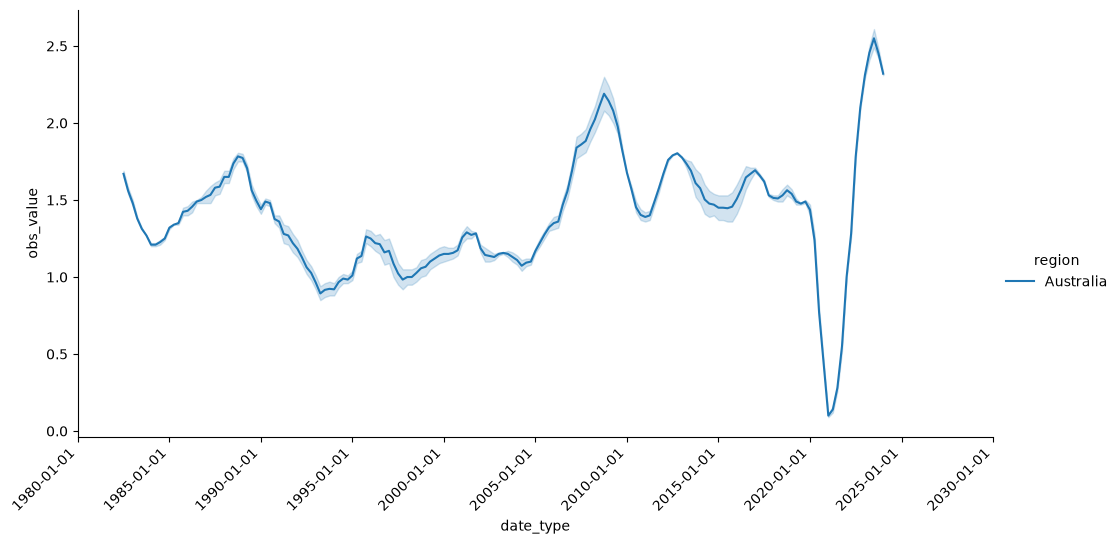

In [329]:
# percentage_change
# use dataset
dataset = percentage_change[(percentage_change['region'] == 'Australia') & (percentage_change['age'] == 'All ages')]
#draft
resident_population_g = sns.relplot(
    data= dataset,
    x="date_type", 
    y="obs_value",
    hue='region',
    kind="line",
    aspect=2
)
# Rotate the x-axis labels for all subplots
resident_population_g.set_xticklabels(rotation=45, ha='right')
#display
display(resident_population_g)

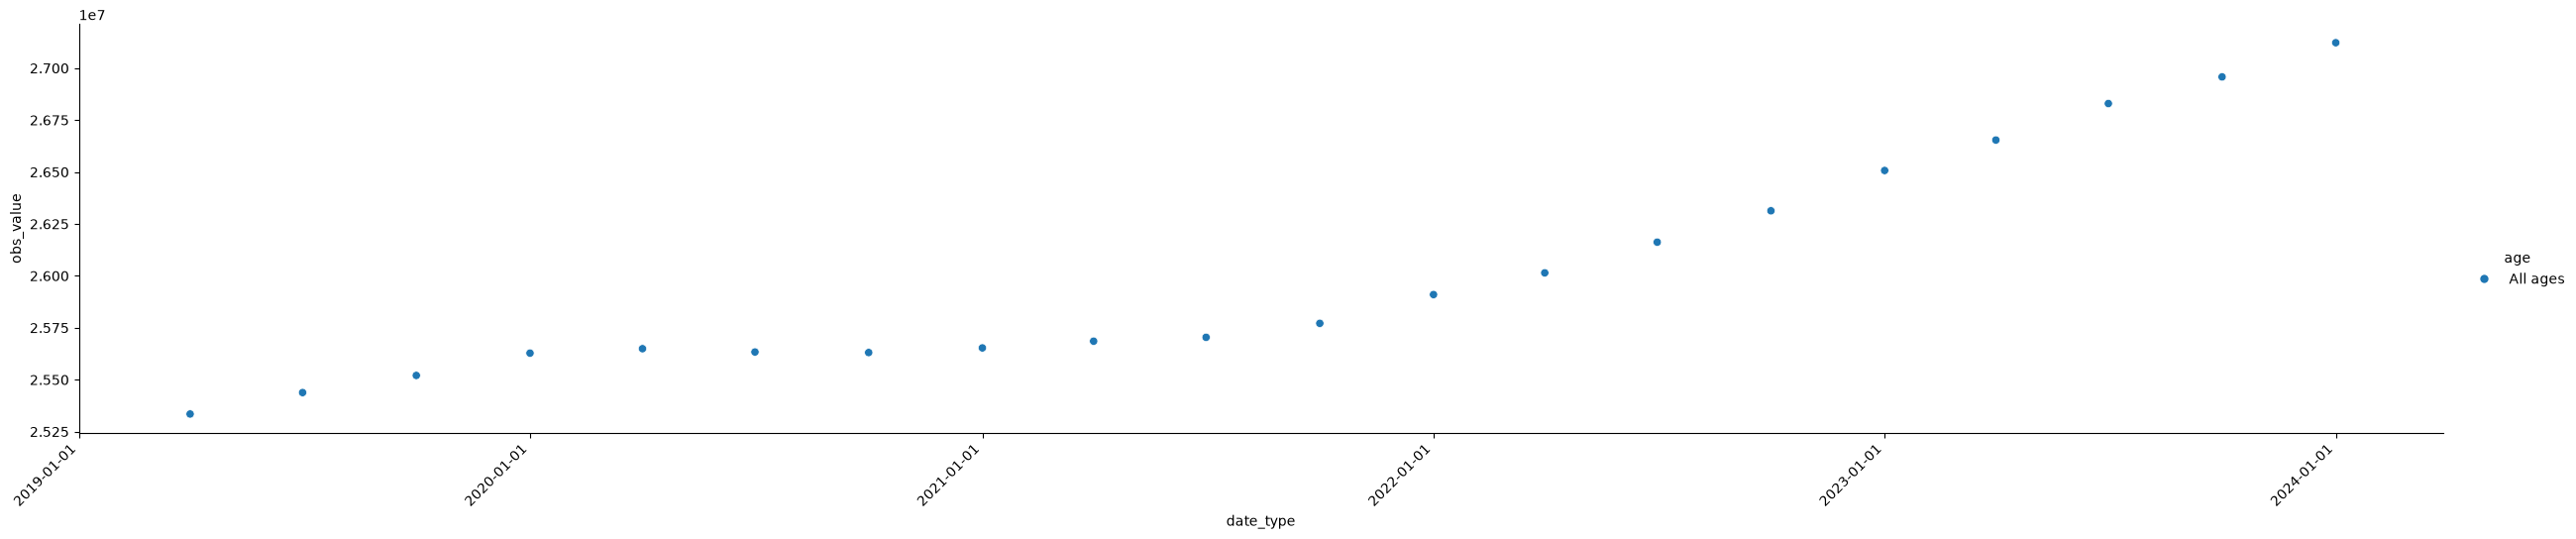

In [327]:
#resident_population
# use dataset
dataset = resident_population[(resident_population['region']=='Australia') & (resident_population['sex']=='Persons') & (resident_population['age'] == 'All ages') & (resident_population['date_type']>'2019-01-01')]
#draft
resident_population_g = sns.relplot(
    data= dataset,
    x="date_type", 
    y="obs_value",
    hue='age',
    aspect=5
)
# Rotate the x-axis labels for all subplots
resident_population_g.set_xticklabels(rotation=45, ha='right')
#display
display(resident_population_g)

Summary: the increase of population slows down after 2020 and rise again at the end of 2021. That is why there is a huge drop at 'ERP Change Over Previous Year' and 'ERP Persentage Change Over Previous Year'.


In [387]:
columns = ['sex', 'region', 'age', 'date_type']
resident_population = resident_population.sort_values(by=columns).reset_index()
percentage_change = percentage_change.sort_values(by=columns).reset_index()

resident_population.head()

,index,measure,sex,age,region,time_period,obs_value,date_type,recalculated_pct_change,percentage_change
0,18639,Estimated Resident Population,Females,0,Australia,1981-Q3,114277.0,1981-07-01,NaN,NaN
1,18640,Estimated Resident Population,Females,0,Australia,1981-Q4,112822.0,1981-10-01,NaN,NaN
2,18641,Estimated Resident Population,Females,0,Australia,1982-Q1,113956.0,1982-01-01,NaN,NaN
3,18642,Estimated Resident Population,Females,0,Australia,1982-Q2,114979.0,1982-04-01,NaN,NaN
4,18643,Estimated Resident Population,Females,0,Australia,1982-Q3,115498.0,1982-07-01,1.068456,NaN


In [394]:
resident_population["recalculated_pct_change"] = resident_population[
    "obs_value"
].pct_change(periods = 4)*100

In [396]:
resident_population["percentage_change"] = percentage_change[
    "obs_value"
]

In [397]:
resident_population.head(10)

,index,measure,sex,age,region,time_period,obs_value,date_type,recalculated_pct_change,percentage_change
0,18639,Estimated Resident Population,Females,0,Australia,1981-Q3,114277.0,1981-07-01,NaN,NaN
1,18640,Estimated Resident Population,Females,0,Australia,1981-Q4,112822.0,1981-10-01,NaN,NaN
2,18641,Estimated Resident Population,Females,0,Australia,1982-Q1,113956.0,1982-01-01,NaN,NaN
3,18642,Estimated Resident Population,Females,0,Australia,1982-Q2,114979.0,1982-04-01,NaN,NaN
4,18643,Estimated Resident Population,Females,0,Australia,1982-Q3,115498.0,1982-07-01,1.068456,1.07
5,18644,Estimated Resident Population,Females,0,Australia,1982-Q4,115082.0,1982-10-01,2.003155,2.00
6,18645,Estimated Resident Population,Females,0,Australia,1983-Q1,116126.0,1983-01-01,1.904244,1.90
7,18646,Estimated Resident Population,Females,0,Australia,1983-Q2,116956.0,1983-04-01,1.719444,1.72
8,18647,Estimated Resident Population,Females,0,Australia,1983-Q3,117741.0,1983-07-01,1.942025,1.94
9,18648,Estimated Resident Population,Females,0,Australia,1983-Q4,116582.0,1983-10-01,1.303418,1.30


In [401]:
# 3. Measure the absolute discrepancy
resident_population["pct_discrepancy"] = (
    resident_population["percentage_change"]
    - resident_population["recalculated_pct_change"]
).abs()

# 4. Flag any row where the mathematical difference is noticeable
# We use 0.0001 (or 0.01%) to account for minor rounding variations
tolerance = 0.01
resident_population["is_pct_change_error"] = (
    resident_population["pct_discrepancy"] > tolerance
)

In [404]:
resident_population[resident_population['is_pct_change_error'] == True]

,index,measure,sex,age,region,time_period,obs_value,date_type,recalculated_pct_change,percentage_change,pct_discrepancy,is_pct_change_error


Summary: Calculate the percentage change again and compare with the given data. The data given has no error inputs. 


#### Find primary key

In [ ]:
# find primary key
columns = ['measure', 'sex', 'age', 'region', 'time_period']
is_not_unique = not erp_quarterly_original[columns].duplicated().any()
print(f'this/these columns {columns} can use as primary: {is_not_unique}')

#### Summary of ERP_Quarterly!

**Missing value**: the missing values are only under 'ERP Change Over Previous Year' and 'ERP Percentage Change Over Previous Year' in 'measure'. After futher investigation, we found out that the missing values in 'ERP Change Over Previous Year' are occure in four time period only, 1982-Q2, 1982-Q1, 1981-Q4 and 1981-Q3. In the mean while, the missing value in 'ERP Percentage Change Over Previous Year' ont only includes in those four time period but also other time periods. 

Over all, there are more missing values in the older time in ERP Percentage Change Over Previous Year, and less in recent years. 

**Data type**: age is in str datatype. It has sigular number and range-group. We will currently keep it as it is and futher investigate during data wrangling stage. time_period is in str datatype, we updeted to qualterly period. 


### JobVacancies_states

In [200]:
job_vacancies_state_original= dataframes['job_vacancies_state_original'].copy()

In [201]:
job_vacancies_state_original.head()

,date,series_id,state,variable,series_type,value
0,1979-05-15,A590714V,New South Wales,Job Vacancies,Original,NaN
1,1979-08-15,A590714V,New South Wales,Job Vacancies,Original,NaN
2,1979-11-15,A590714V,New South Wales,Job Vacancies,Original,NaN
3,1980-02-15,A590714V,New South Wales,Job Vacancies,Original,NaN
4,1980-05-15,A590714V,New South Wales,Job Vacancies,Original,NaN


In [202]:
job_vacancies_state_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 3780 entries, 0 to 3779
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3780 non-null   datetime64[us]
 1   series_id    3780 non-null   str           
 2   state        3780 non-null   str           
 3   variable     3780 non-null   str           
 4   series_type  3780 non-null   str           
 5   value        3338 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(4)
memory usage: 366.3 KB


In [204]:
# find duplicate of each observation
has_duplicates = job_vacancies_state_original.duplicated().any()
print(has_duplicates)

False


In [210]:
# find duplicate in each column
for one in job_vacancies_state_original.columns:
    individual_values = job_vacancies_state_original[one].is_unique
    print(f'{one} are unique:{individual_values}')

date are unique:False
series_id are unique:False
state are unique:False
variable are unique:False
series_type are unique:False
value are unique:False


In [240]:
# get range of each variables
for v in job_vacancies_state_original['variable'].unique():
    describe = job_vacancies_state_original[job_vacancies_state_original['variable'] == v].describe()
    display(describe)

,date,value
count,2079,1880.000000
mean,2002-11-14 18:40:00,54.626596
min,1979-05-15 00:00:00,0.000000
25%,1991-02-15 00:00:00,4.800000
50%,2002-11-15 00:00:00,24.150000
75%,2014-08-15 00:00:00,69.525000
max,2026-05-15 00:00:00,475.000000
std,NaN,81.355529


,date,value
count,1701,1458.000000
mean,2002-11-14 18:40:00,2.681550
min,1979-05-15 00:00:00,0.000000
25%,1991-02-15 00:00:00,0.600000
50%,2002-11-15 00:00:00,1.850000
75%,2014-08-15 00:00:00,4.100000
max,2026-05-15 00:00:00,13.500000
std,NaN,2.505135


#### Missing value further investigation:

In [212]:
missing_value = job_vacancies_state_original[
    job_vacancies_state_original['value'].isnull()
]

In [217]:
print(f'columns: {missing_value.columns}')
for c in missing_value.columns:
    columns = c
    unique_value = missing_value[columns].unique()
    print(f'{c}:')
    print(f'{unique_value}')
    print('')

columns: Index(['date', 'series_id', 'state', 'variable', 'series_type', 'value'], dtype='str')
date:
<DatetimeArray>
['1979-05-15 00:00:00', '1979-08-15 00:00:00', '1979-11-15 00:00:00',
 '1980-02-15 00:00:00', '1980-05-15 00:00:00', '1980-08-15 00:00:00',
 '1980-11-15 00:00:00', '1981-02-15 00:00:00', '1981-05-15 00:00:00',
 '1981-08-15 00:00:00', '1981-11-15 00:00:00', '1982-02-15 00:00:00',
 '1982-05-15 00:00:00', '1982-08-15 00:00:00', '1982-11-15 00:00:00',
 '1983-02-15 00:00:00', '1983-05-15 00:00:00', '1983-08-15 00:00:00',
 '2008-08-15 00:00:00', '2008-11-15 00:00:00', '2009-02-15 00:00:00',
 '2009-05-15 00:00:00', '2009-08-15 00:00:00', '1983-11-15 00:00:00',
 '1984-02-15 00:00:00', '1984-05-15 00:00:00', '1984-08-15 00:00:00']
Length: 27, dtype: datetime64[us]

series_id:
<ArrowStringArray>
['A590714V', 'A590732X', 'A590750C', 'A590768A', 'A590786F', 'A590804X',
 'A590822C', 'A590840J', 'A590696A', 'A590698F', 'A590700F', 'A590715W',
 'A590733A', 'A590751F', 'A590769C', 'A59

#### Summary of JobVacancies_states!

**Missing value**: Data is completely missing between 1979 and 1984, with additional gaps occurring in 2008 and 2009.


In [223]:
# find primary key
columns = ['date', 'series_id']
is_not_unique = not job_vacancies_state_original[columns].duplicated().any()
print(f'this/these columns {columns} can use as primary: {is_not_unique}')

this/these columns ['date', 'series_id'] can use as primary: True


### HourlyWagesRates_Industry

In [273]:
hourly_wages_rates_industry_original= dataframes['hourly_wages_rates_industry_original'].copy()

In [274]:
hourly_wages_rates_industry_original.head()

,date,series_id,location,company_type,industry,index,value
0,1997-09-01,A2602939F,Australia,Private,Mining,Quarterly Index,64.0
1,1997-12-01,A2602939F,Australia,Private,Mining,Quarterly Index,64.4
2,1998-03-01,A2602939F,Australia,Private,Mining,Quarterly Index,64.9
3,1998-06-01,A2602939F,Australia,Private,Mining,Quarterly Index,65.2
4,1998-09-01,A2602939F,Australia,Private,Mining,Quarterly Index,65.6


In [226]:
hourly_wages_rates_industry_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 15180 entries, 0 to 15179
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          15180 non-null  datetime64[us]
 1   series_id     15180 non-null  str           
 2   location      15180 non-null  str           
 3   company_type  15180 non-null  str           
 4   industry      15180 non-null  str           
 5   value         14960 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(4)
memory usage: 1.5 MB


In [228]:
# find duplicate of each observation
has_duplicates = hourly_wages_rates_industry_original.duplicated().any()
print(has_duplicates)

False


In [229]:
# find duplicate in each column
for one in hourly_wages_rates_industry_original.columns:
    individual_values = hourly_wages_rates_industry_original[one].is_unique
    print(f'{one} are unique:{individual_values}')

date are unique:False
series_id are unique:False
location are unique:False
company_type are unique:False
industry are unique:False
value are unique:False


In [231]:
hourly_wages_rates_industry_original.describe()

,date,value
count,15180,14960.000000
mean,2011-12-01 02:17:44.347826,38.210047
min,1997-09-01 00:00:00,-1.000000
25%,2004-09-01 00:00:00,1.000000
50%,2011-12-01 00:00:00,3.200000
75%,2019-03-01 00:00:00,85.600000
max,2026-03-01 00:00:00,173.600000
std,NaN,53.119517


In [247]:
# get range of each variables
for v in hourly_wages_rates_industry_original['company_type'].unique():
    describe = hourly_wages_rates_industry_original[hourly_wages_rates_industry_original['company_type'] == v].describe()
    print(v)
    display(describe)

Private


,date,value
count,6555,6460.000000
mean,2011-12-01 02:17:44.347826,38.159241
min,1997-09-01 00:00:00,-1.000000
25%,2004-09-01 00:00:00,1.000000
50%,2011-12-01 00:00:00,3.100000
75%,2019-03-01 00:00:00,85.725000
max,2026-03-01 00:00:00,173.600000
std,NaN,53.036930


Public


,date,value
count,2070,2040.000000
mean,2011-12-01 02:17:44.347826,38.520196
min,1997-09-01 00:00:00,0.000000
25%,2004-09-01 00:00:00,1.100000
50%,2011-12-01 00:00:00,3.400000
75%,2019-03-01 00:00:00,84.500000
max,2026-03-01 00:00:00,171.800000
std,NaN,53.653206


Private and Public


,date,value
count,6555,6460.000000
mean,2011-12-01 02:17:44.347826,38.162910
min,1997-09-01 00:00:00,-0.900000
25%,2004-09-01 00:00:00,1.000000
50%,2011-12-01 00:00:00,3.100000
75%,2019-03-01 00:00:00,85.600000
max,2026-03-01 00:00:00,171.300000
std,NaN,53.040552


#### Missing value further investigation:

In [302]:
missing_value = hourly_wages_rates_industry_original[
    hourly_wages_rates_industry_original['value'].isnull()
]
missing_value

,date,series_id,location,company_type,industry,index,value
5060,1997-09-01,A2602940R,Australia,Private,Mining,Percentage Change from Previous Quarter,NaN
5175,1997-09-01,A2602960X,Australia,Private,Manufacturing,Percentage Change from Previous Quarter,NaN
5290,1997-09-01,A2602920F,Australia,Private,"Electricity, gas, water and waste services",Percentage Change from Previous Quarter,NaN
5405,1997-09-01,A2603020T,Australia,Private,Construction,Percentage Change from Previous Quarter,NaN
5520,1997-09-01,A2603000J,Australia,Private,Wholesale trade,Percentage Change from Previous Quarter,NaN
...,...,...,...,...,...,...,...
14953,1998-06-01,A2603581T,Australia,Private and Public,Other services,Percentage Change from Corresponding Quarter o...,NaN
15065,1997-09-01,A2603611V,Australia,Private and Public,All industries,Percentage Change from Corresponding Quarter o...,NaN
15066,1997-12-01,A2603611V,Australia,Private and Public,All industries,Percentage Change from Corresponding Quarter o...,NaN
15067,1998-03-01,A2603611V,Australia,Private and Public,All industries,Percentage Change from Corresponding Quarter o...,NaN


In [364]:
hourly_wages_rates_industry_original['index'].unique()

<ArrowStringArray>
[                                              'Quarterly Index',
                       'Percentage Change from Previous Quarter',
 'Percentage Change from Corresponding Quarter of Previous Year']
Length: 3, dtype: str

In [386]:
missing_value['date'].unique()

<DatetimeArray>
['1997-09-01 00:00:00', '1997-12-01 00:00:00', '1998-03-01 00:00:00',
 '1998-06-01 00:00:00']
Length: 4, dtype: datetime64[us]

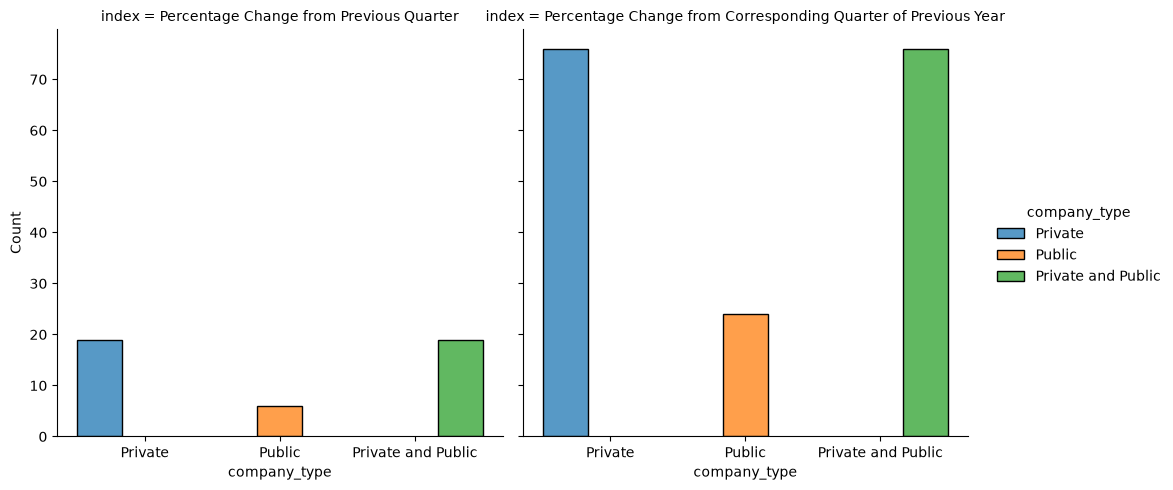

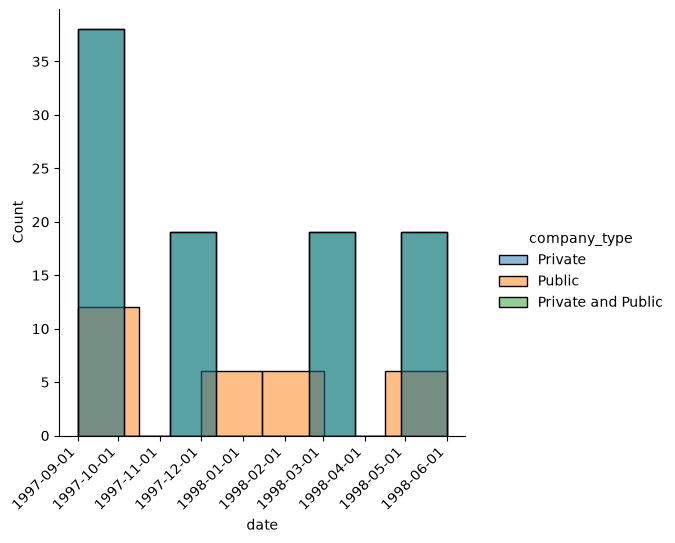

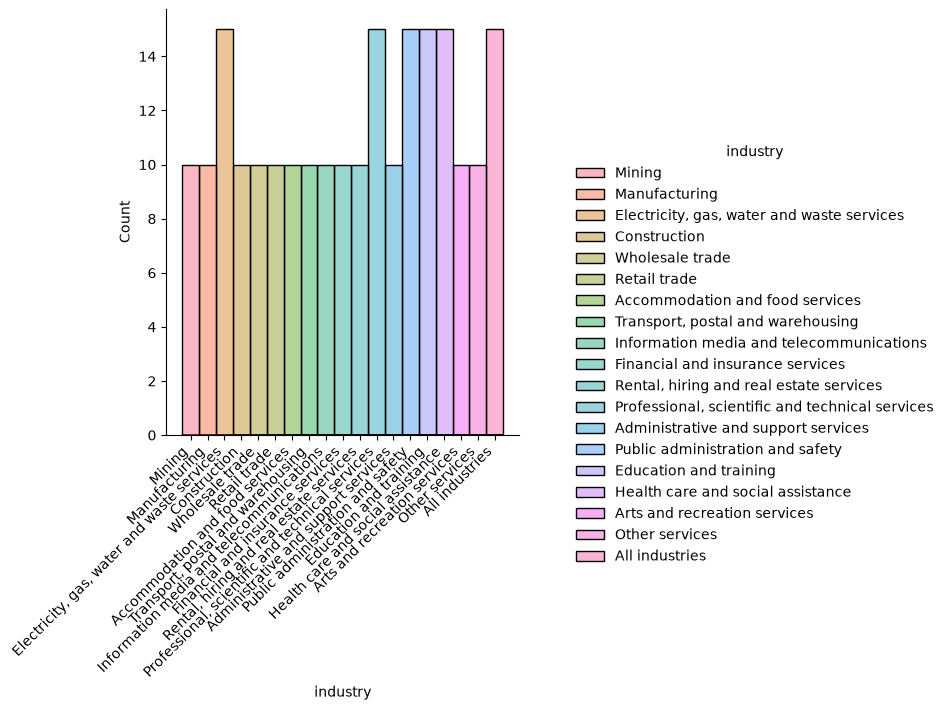

In [388]:
g = sns.displot(
    missing_value, 
    x='company_type', 
    kind='hist', 
    hue='company_type', 
    col='index',
    multiple='dodge',
    common_bins=False
)
g = sns.displot(
    missing_value, 
    x='date', 
    kind='hist', 
    hue='company_type', 
    common_bins=False
)
# Rotate the x-axis labels for all subplots
g.set_xticklabels(rotation=45, ha='right')

g = sns.displot(
    missing_value, 
    x='industry', 
    kind='hist', 
    hue='industry'
)
# Rotate the x-axis labels for all subplots
g.set_xticklabels(rotation=45, ha='right')

#### Statistic analysis of obs_values

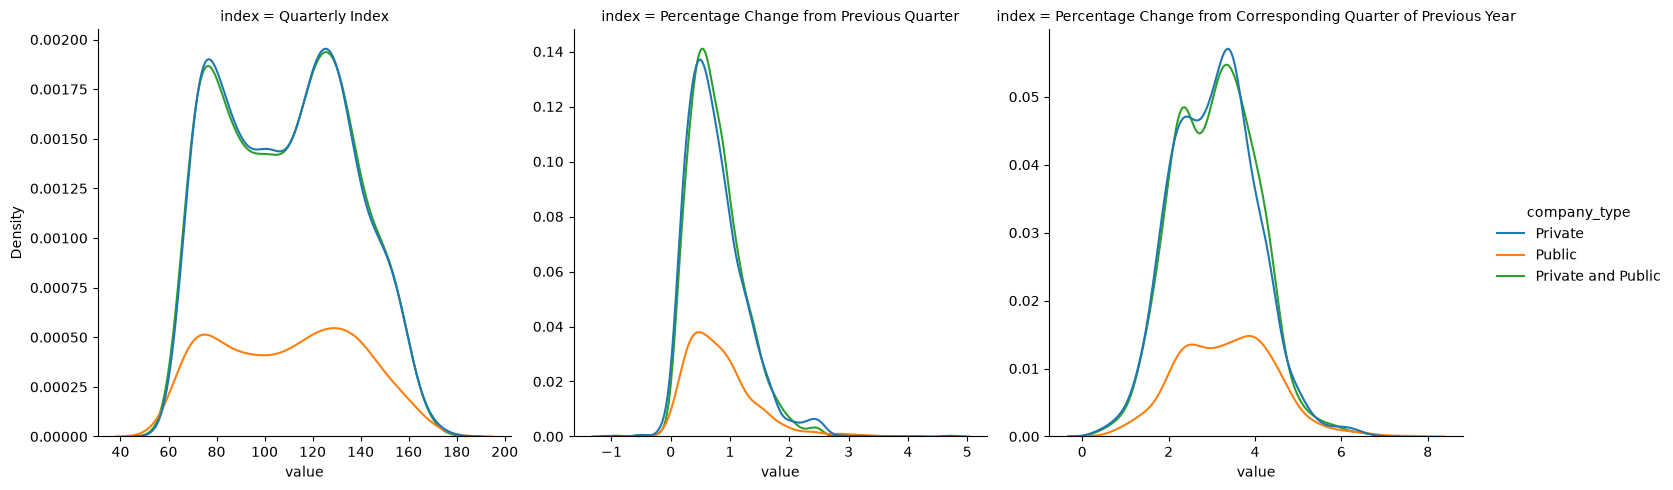

In [349]:
g = sns.displot(
    hourly_wages_rates_industry_original, 
    x='value', 
    kind='kde', 
    hue='company_type', 
    col='index',
    facet_kws={'sharex': False, 'sharey': False} 
)

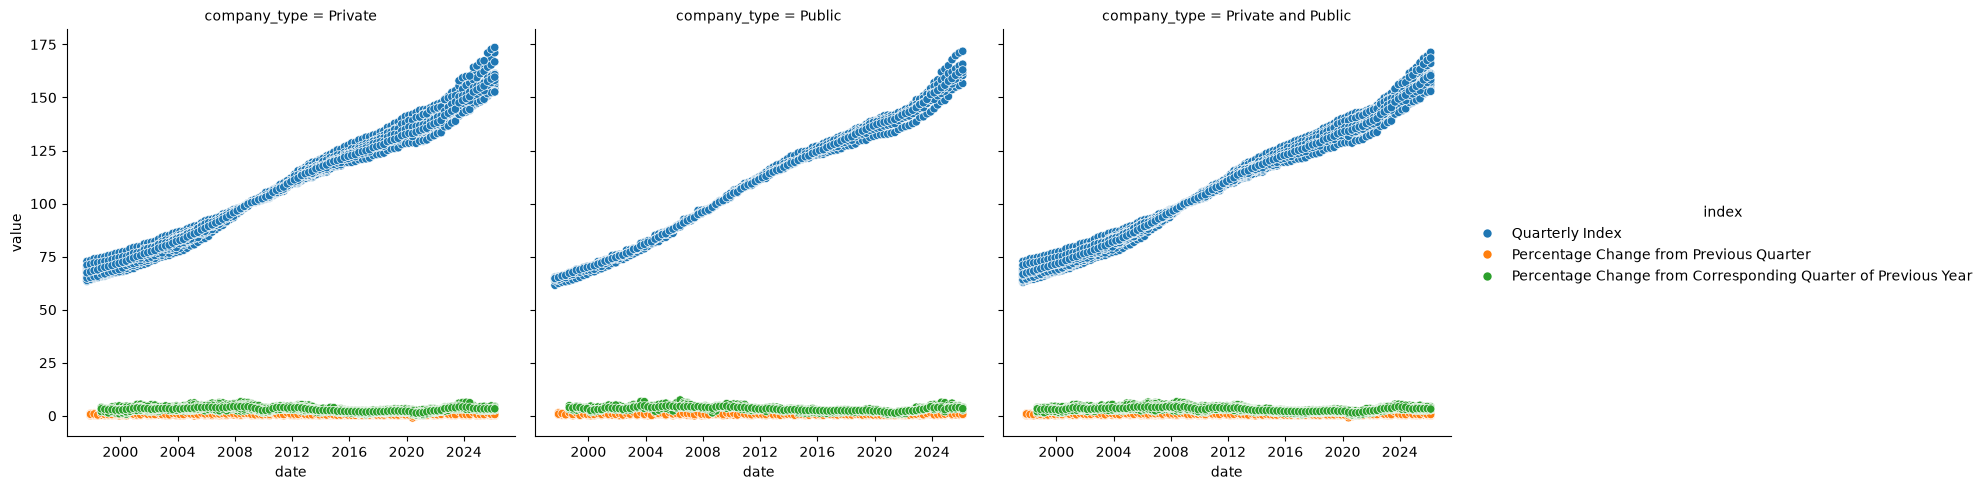

In [283]:
g = sns.relplot(
    data=hourly_wages_rates_industry_original,
    x='date', 
    y='value',
    col = 'company_type',
    hue = 'index'
)

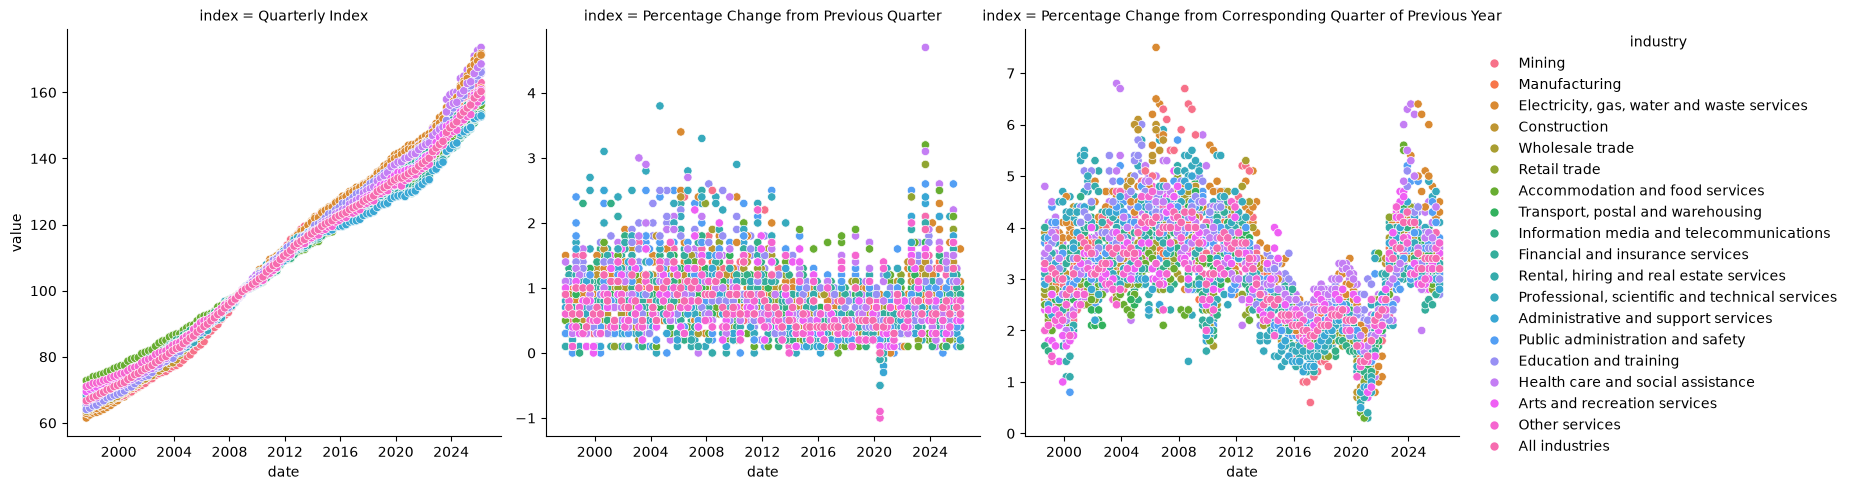

In [284]:
g = sns.relplot(
    data=hourly_wages_rates_industry_original,
    x='date', 
    y='value',
    col = 'index',
    hue = 'industry',
    facet_kws={'sharex': False, 'sharey': False} 
)

In [296]:
columns = ['a']
set(columns).issubset(hourly_wages_rates_industry_original.columns)

False

In [299]:
# find primary key
columns = ['date', 'series_id']
if len(columns) == 0:
    print('please input a column in the list \'columns\' ')
elif set(columns).issubset(hourly_wages_rates_industry_original.columns) == False:
    print('the given column name is not in the dataset')
else:
    is_not_unique = not hourly_wages_rates_industry_original[columns].duplicated().any()
    print(f'this/these columns {columns} can use as primary: {is_not_unique}')

this/these columns ['date', 'series_id'] can use as primary: True


#### Summary of JobVacancies_states!

**Missing value**:\
Specific Time Periods: A separate set of missing values occurs across only four specific periods: 1997-09-01, 1997-12-01, 1998-03-01, and 1998-06-01.Among these, 1997-09-01 contains the highest volume of missing data, while the remaining three periods are evenly distributed.\
Feature Distribution: Feature-wise, private companies exhibit more missing data than public companies. The vast majority of null values are concentrated in Percentage Change from Previous Quarter, with only a few found in Percentage Change from Corresponding Quarter of Previous Year.\
Industry Breakdown: The data visualization indicates that null values are evenly spread across various industry categories. While one specific industry group shows a higher volume of missing data than the others, no definitive relationship or pattern can be found among the industries with higher null counts.\
Conclusion: Overall, the missingness pattern aligns with the Missing at Random (MAR) mechanism. We will keep the mulls in current stage.